In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import thermoift.PLOT_SETTINGS as ps
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
dfs = []

for i in range(100):
    path = f"../DATASET_A1/1682392_{i}/CSV/interfacial_results/feed_1_interfacial_results.csv"
    
    try:
        df = pd.read_csv(path)
        
        # Unrealistic/invalid data
        df = df[
            (df["vapor_density"] < 400) &
            (df["interfacial_thickness"] > 0)
        ]
        
        df["source_id"] = i
        dfs.append(df)
    except FileNotFoundError:
        print(f"Missing: {path}")

combined_df = pd.concat(dfs, ignore_index=True)
combined_df = combined_df.dropna(subset=["gamma"])
combined_df.to_csv("interfacial_results_dataset_A1.csv", index=False)

print(f"Combined {len(dfs)} datasets. Total rows: {len(combined_df)}")

Combined 100 datasets. Total rows: 19171


In [3]:
combined_df = pd.read_csv("interfacial_results_dataset_A1.csv")  

target = "gamma"

COMPONENTS = [
    "carbon dioxide",
    "hydrogen",
    "argon",
    "nitrogen",
    "methane",
    "oxygen",
    "carbon monoxide",
    "hydrogen sulfide"
]

z_columns = [f"z_{comp}" for comp in COMPONENTS]

features = [
    col for col in combined_df.columns
    if col in ["temperature", "pressure"] + z_columns]

print(features)

# Split the data into training and testing sets
X = combined_df[features]
y = combined_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=85)

print(f"Training: {X_train.shape[0]} rows")
print(f"Testing:  {X_test.shape[0]} rows")

['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']
Training: 15336 rows
Testing:  3835 rows


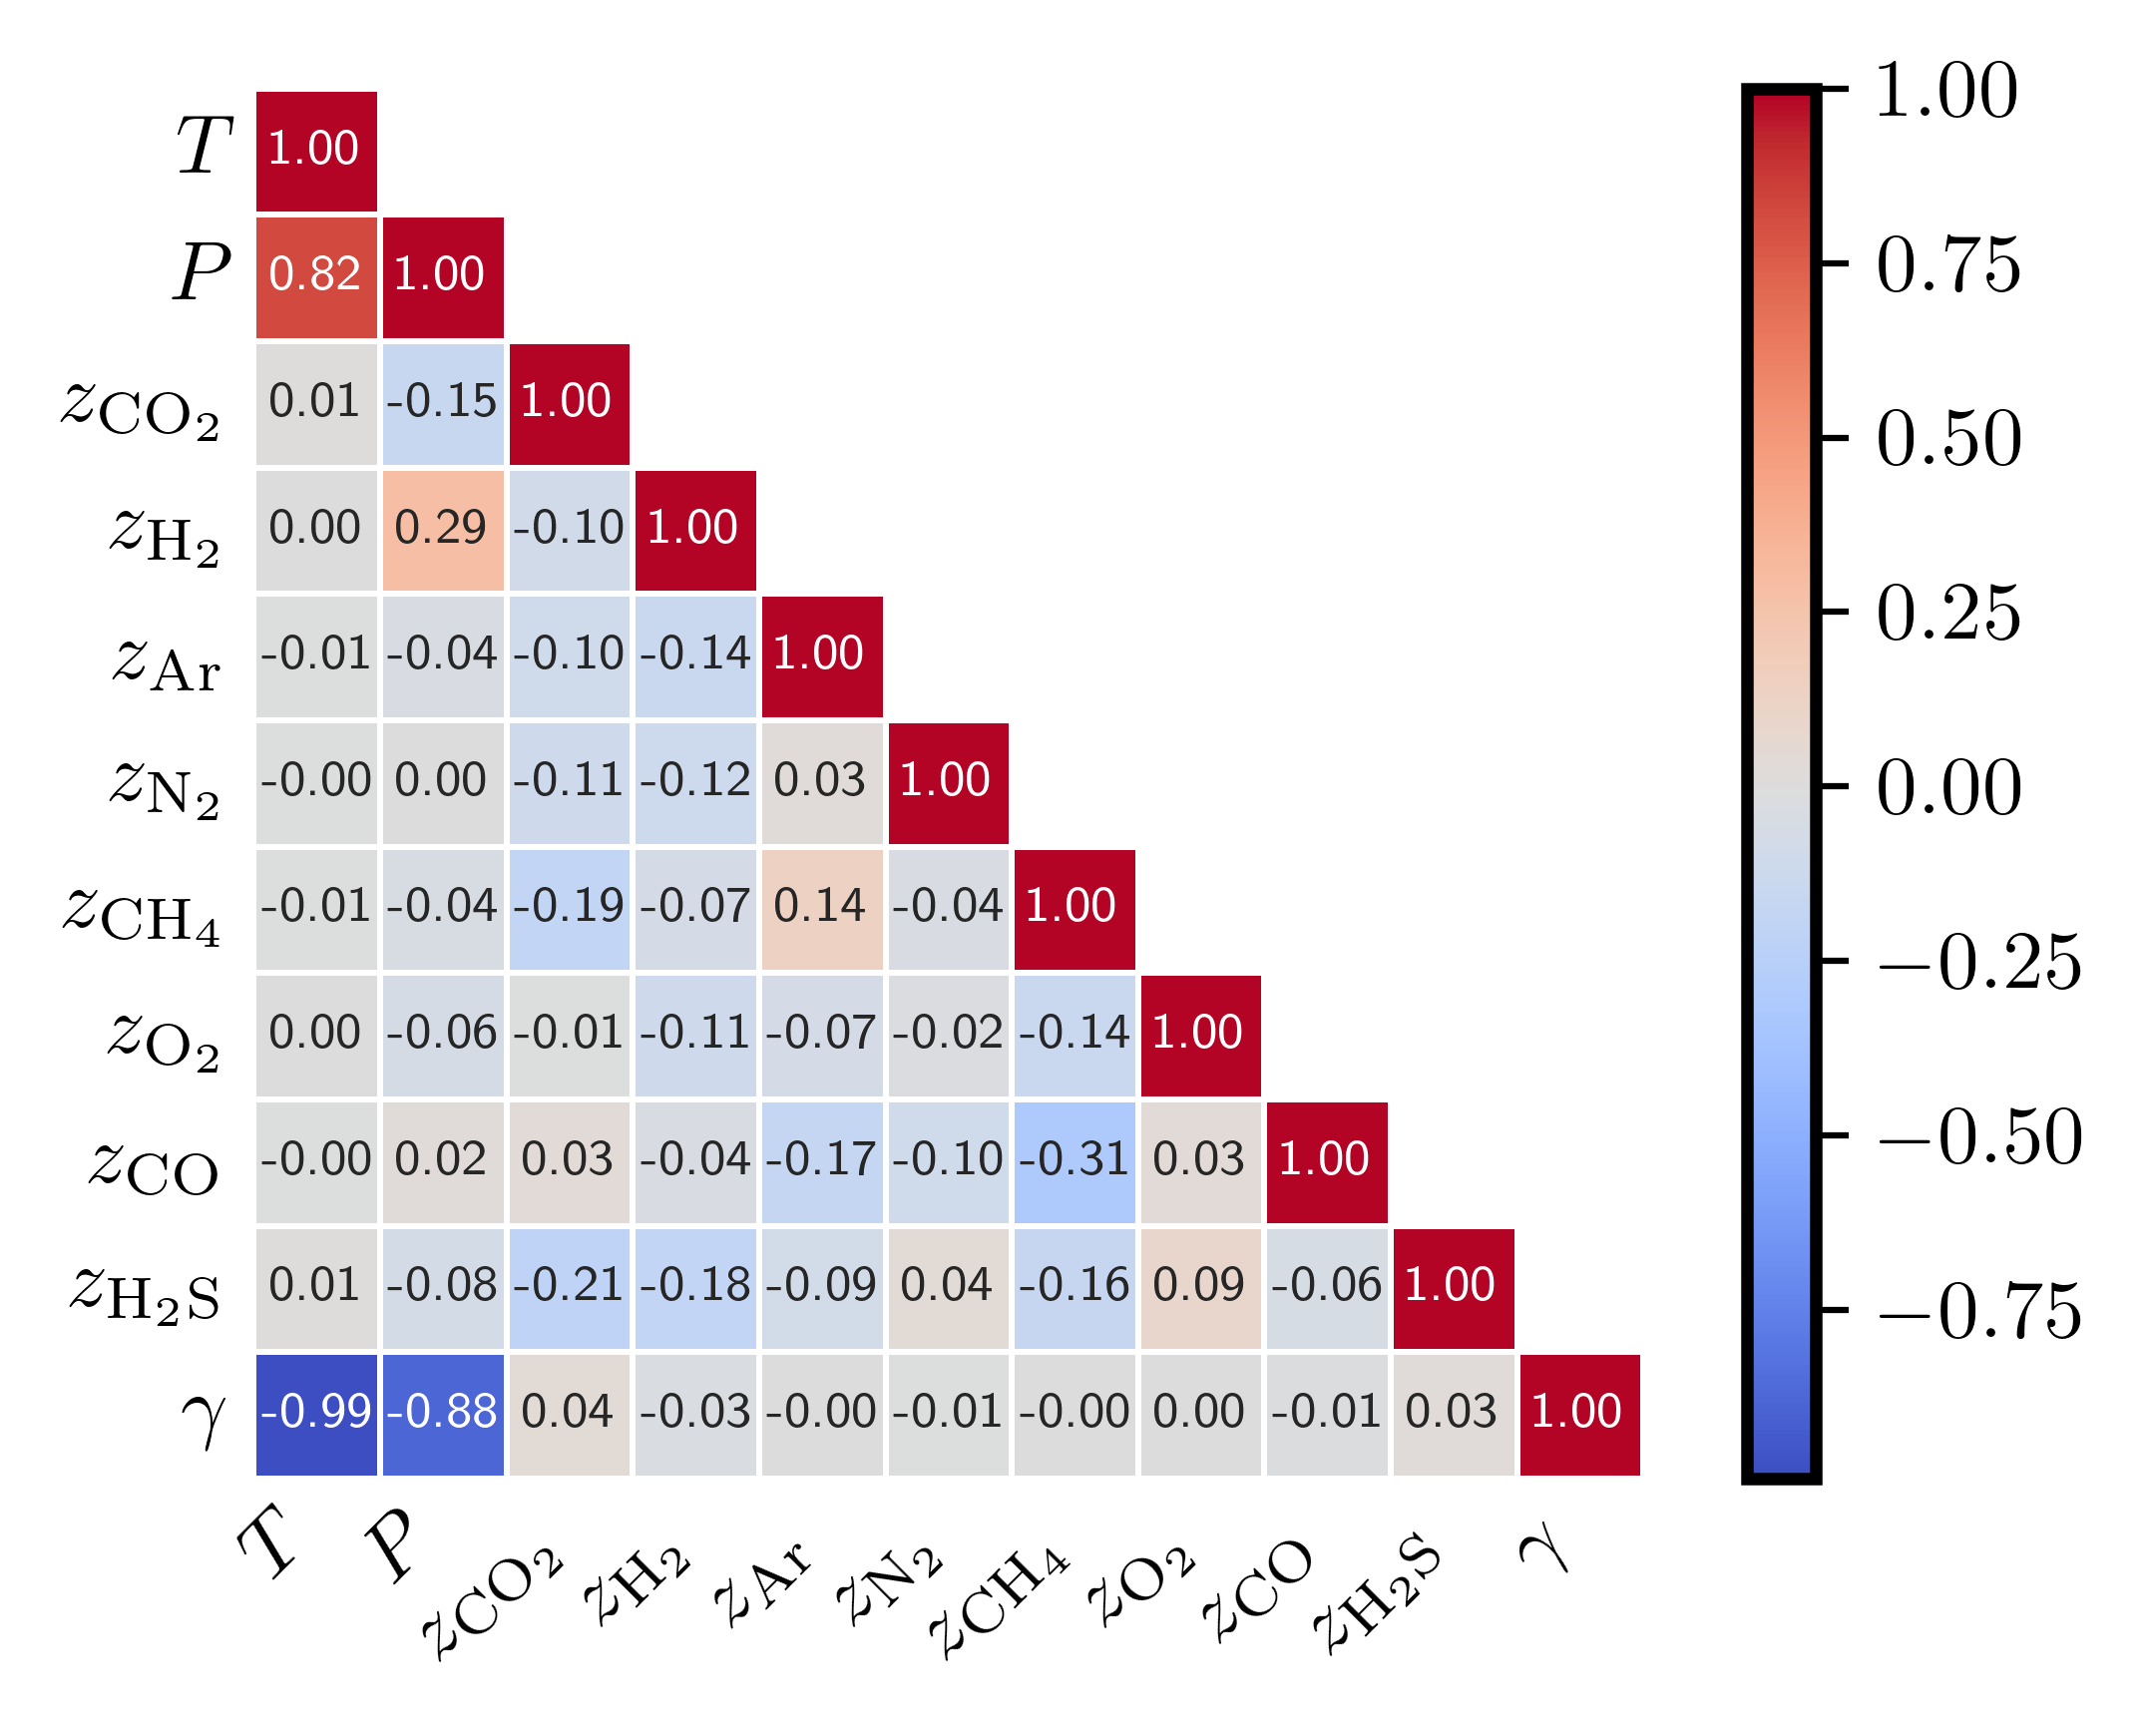

In [4]:
target = "gamma"

COMPONENTS = [
    "carbon dioxide",
    "hydrogen",
    "argon",
    "nitrogen",
    "methane",
    "oxygen",
    "carbon monoxide",
    "hydrogen sulfide"
]

z_cols = [f"z_{comp}" for comp in COMPONENTS if f"z_{comp}" in combined_df.columns]

feature_cols = ["temperature", "pressure"] + z_cols
numeric_cols = feature_cols + [target]

label_map = {
    "temperature": r"$T$",
    "pressure": r"$P$",
    "z_carbon dioxide": r"$z_{\mathrm{CO_2}}$",
    "z_hydrogen": r"$z_{\mathrm{H_2}}$",
    "z_argon": r"$z_{\mathrm{Ar}}$",
    "z_nitrogen": r"$z_{\mathrm{N_2}}$",
    "z_methane": r"$z_{\mathrm{CH_4}}$",
    "z_oxygen": r"$z_{\mathrm{O_2}}$",
    "z_carbon monoxide": r"$z_{\mathrm{CO}}$",
    "z_hydrogen sulfide": r"$z_{\mathrm{H_2S}}$",
    "gamma": r"$\gamma$"
}

numeric_cols = [col for col in numeric_cols if combined_df[col].nunique() > 1]
corr = combined_df[numeric_cols].corr(method="spearman")
corr = corr.rename(index=label_map, columns=label_map)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = ps.plot_init()

cm = sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap=ps.map,
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 6},
    cbar_kws={"shrink": 1.0}
)

cbar = cm.collections[0].colorbar
ps.style_colorbar(cbar)

ps.apply_axis_style(ax)
ax.tick_params(axis="both", length=0)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
ps.save_plot(fig, "feed_1_correlation_triangular")
plt.show()

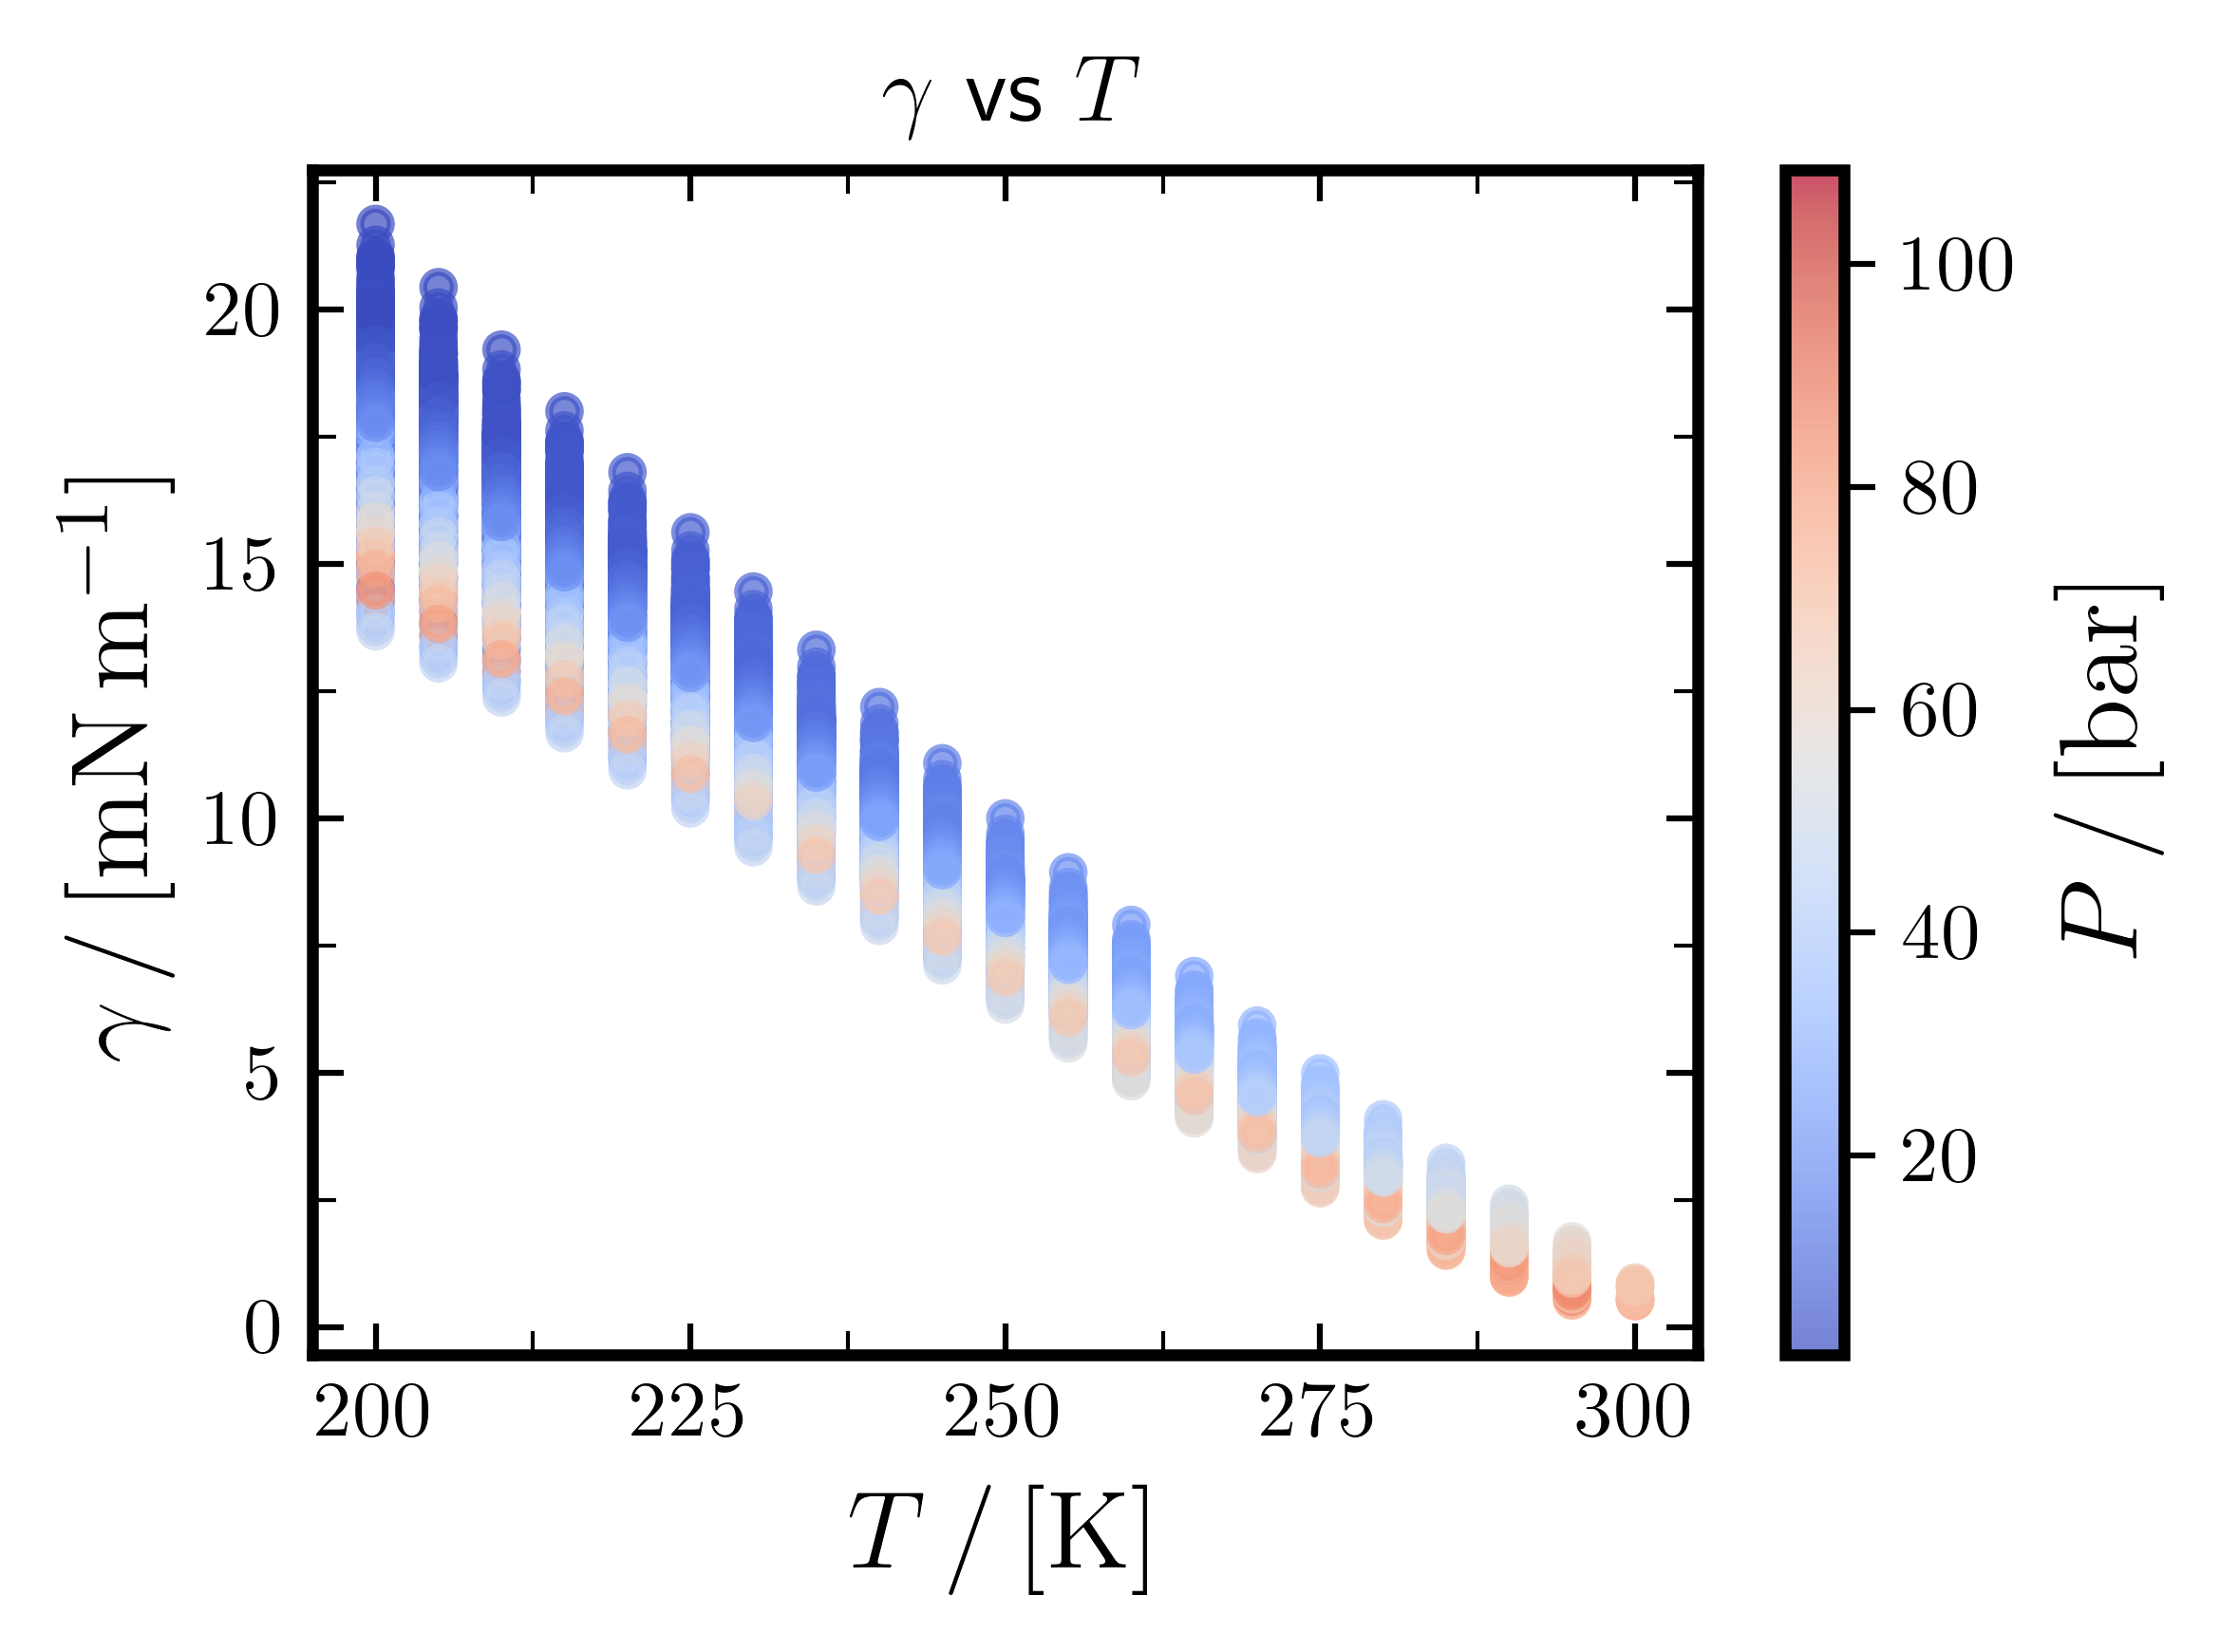

In [5]:
# 1. gamma vs Temperature (colored by Pressure)
fig, ax = ps.plot_init()
sc = ax.scatter(combined_df["temperature"], combined_df["gamma"], c=combined_df["pressure"], cmap=ps.map, s=15, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$P\, / \,[\mathrm{bar}]$", fontsize=ps.label_fontsize)
ps.style_colorbar(cbar)
ax.set_xlabel(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_title(r"$\gamma$ vs $T$", fontsize=ps.title_fontsize, fontweight="bold")
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)
plt.tight_layout()
ps.save_plot(fig, "gamma_vs_T")
plt.show()

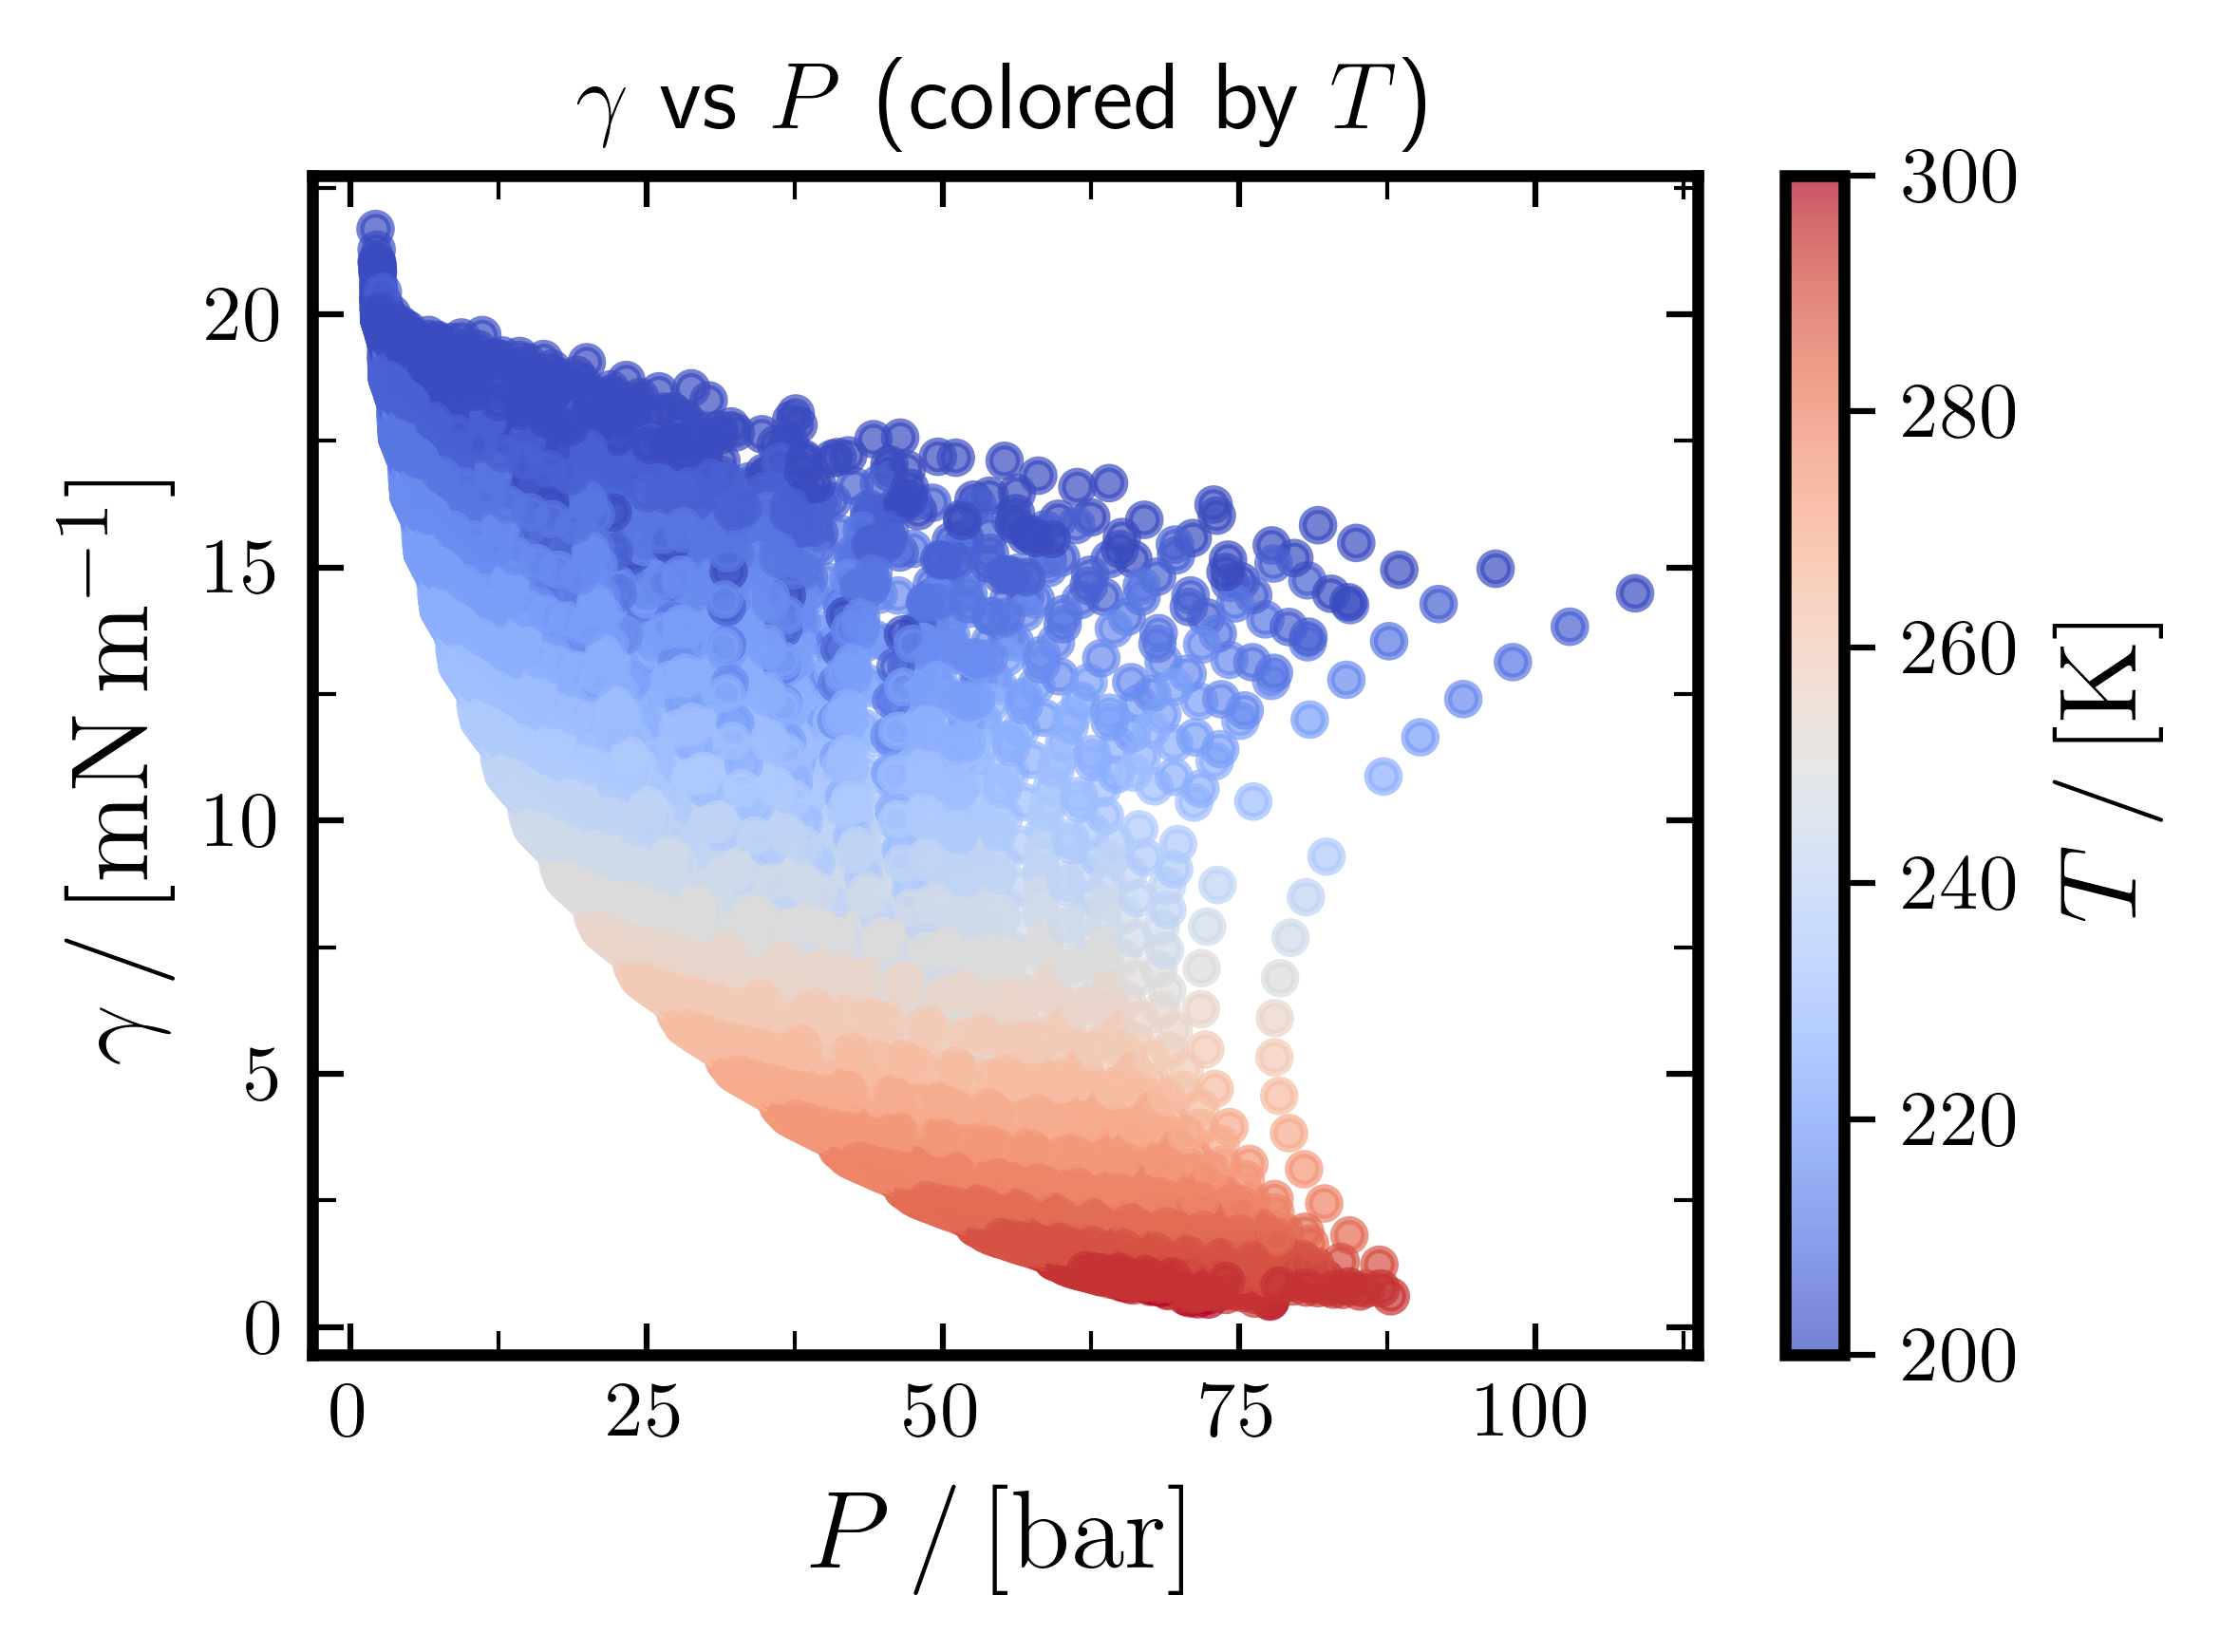

In [6]:
# 2. gamma vs Pressure (colored by Temperature)
fig, ax = ps.plot_init()
sc = ax.scatter(combined_df["pressure"], combined_df["gamma"], c=combined_df["temperature"], cmap=ps.map, s=15, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize)
ps.style_colorbar(cbar)
ax.set_xlabel(r"$P\, / \, [\mathrm{bar}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_title(r"$\gamma$ vs $P$ (colored by $T$)", fontsize=ps.title_fontsize, fontweight="bold")
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)
plt.tight_layout()
ps.save_plot(fig, "gamma_vs_P")
plt.show()

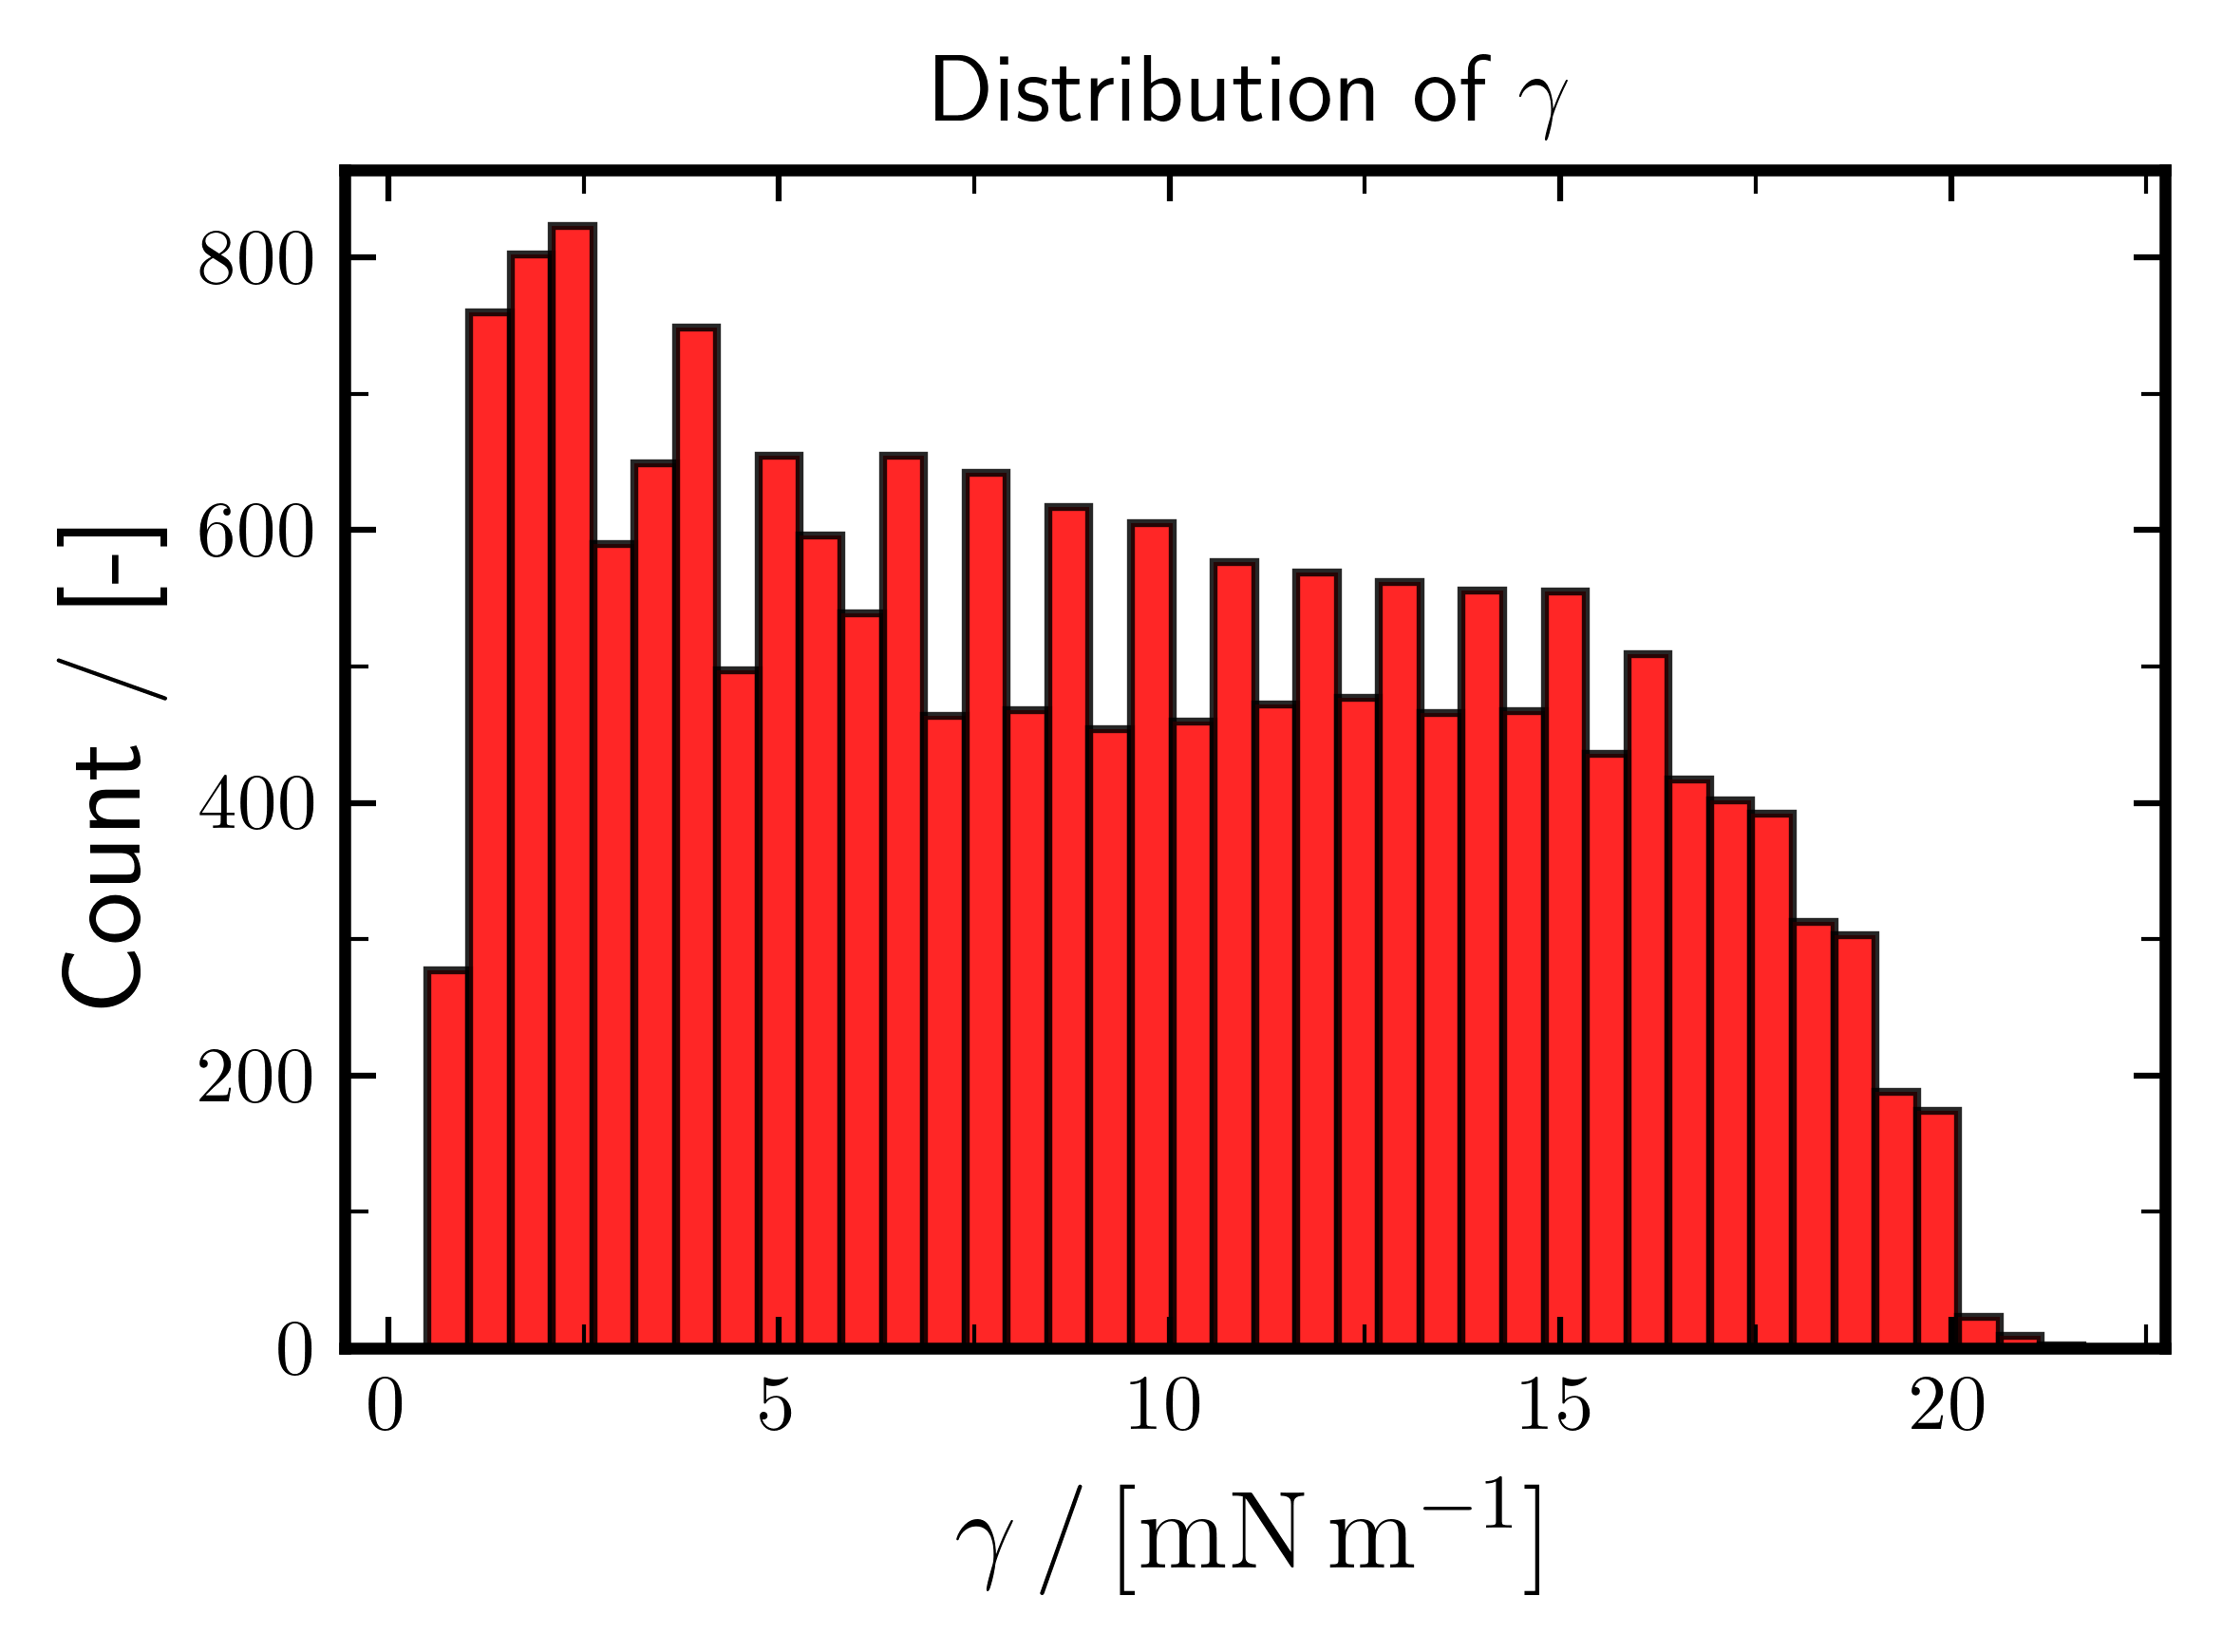

In [7]:
# 3. Distribution of gamma (histogram)
fig, ax = ps.plot_init()
ax.hist(combined_df["gamma"], bins=40, edgecolor="black", color="red", alpha=0.85)
ax.set_xlabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"Count / [-]", fontsize=ps.label_fontsize)
ax.set_title(r"Distribution of $\gamma$", fontsize=ps.title_fontsize, fontweight="bold")
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)
plt.tight_layout()
ps.save_plot(fig, "gamma_distribution")
plt.show()

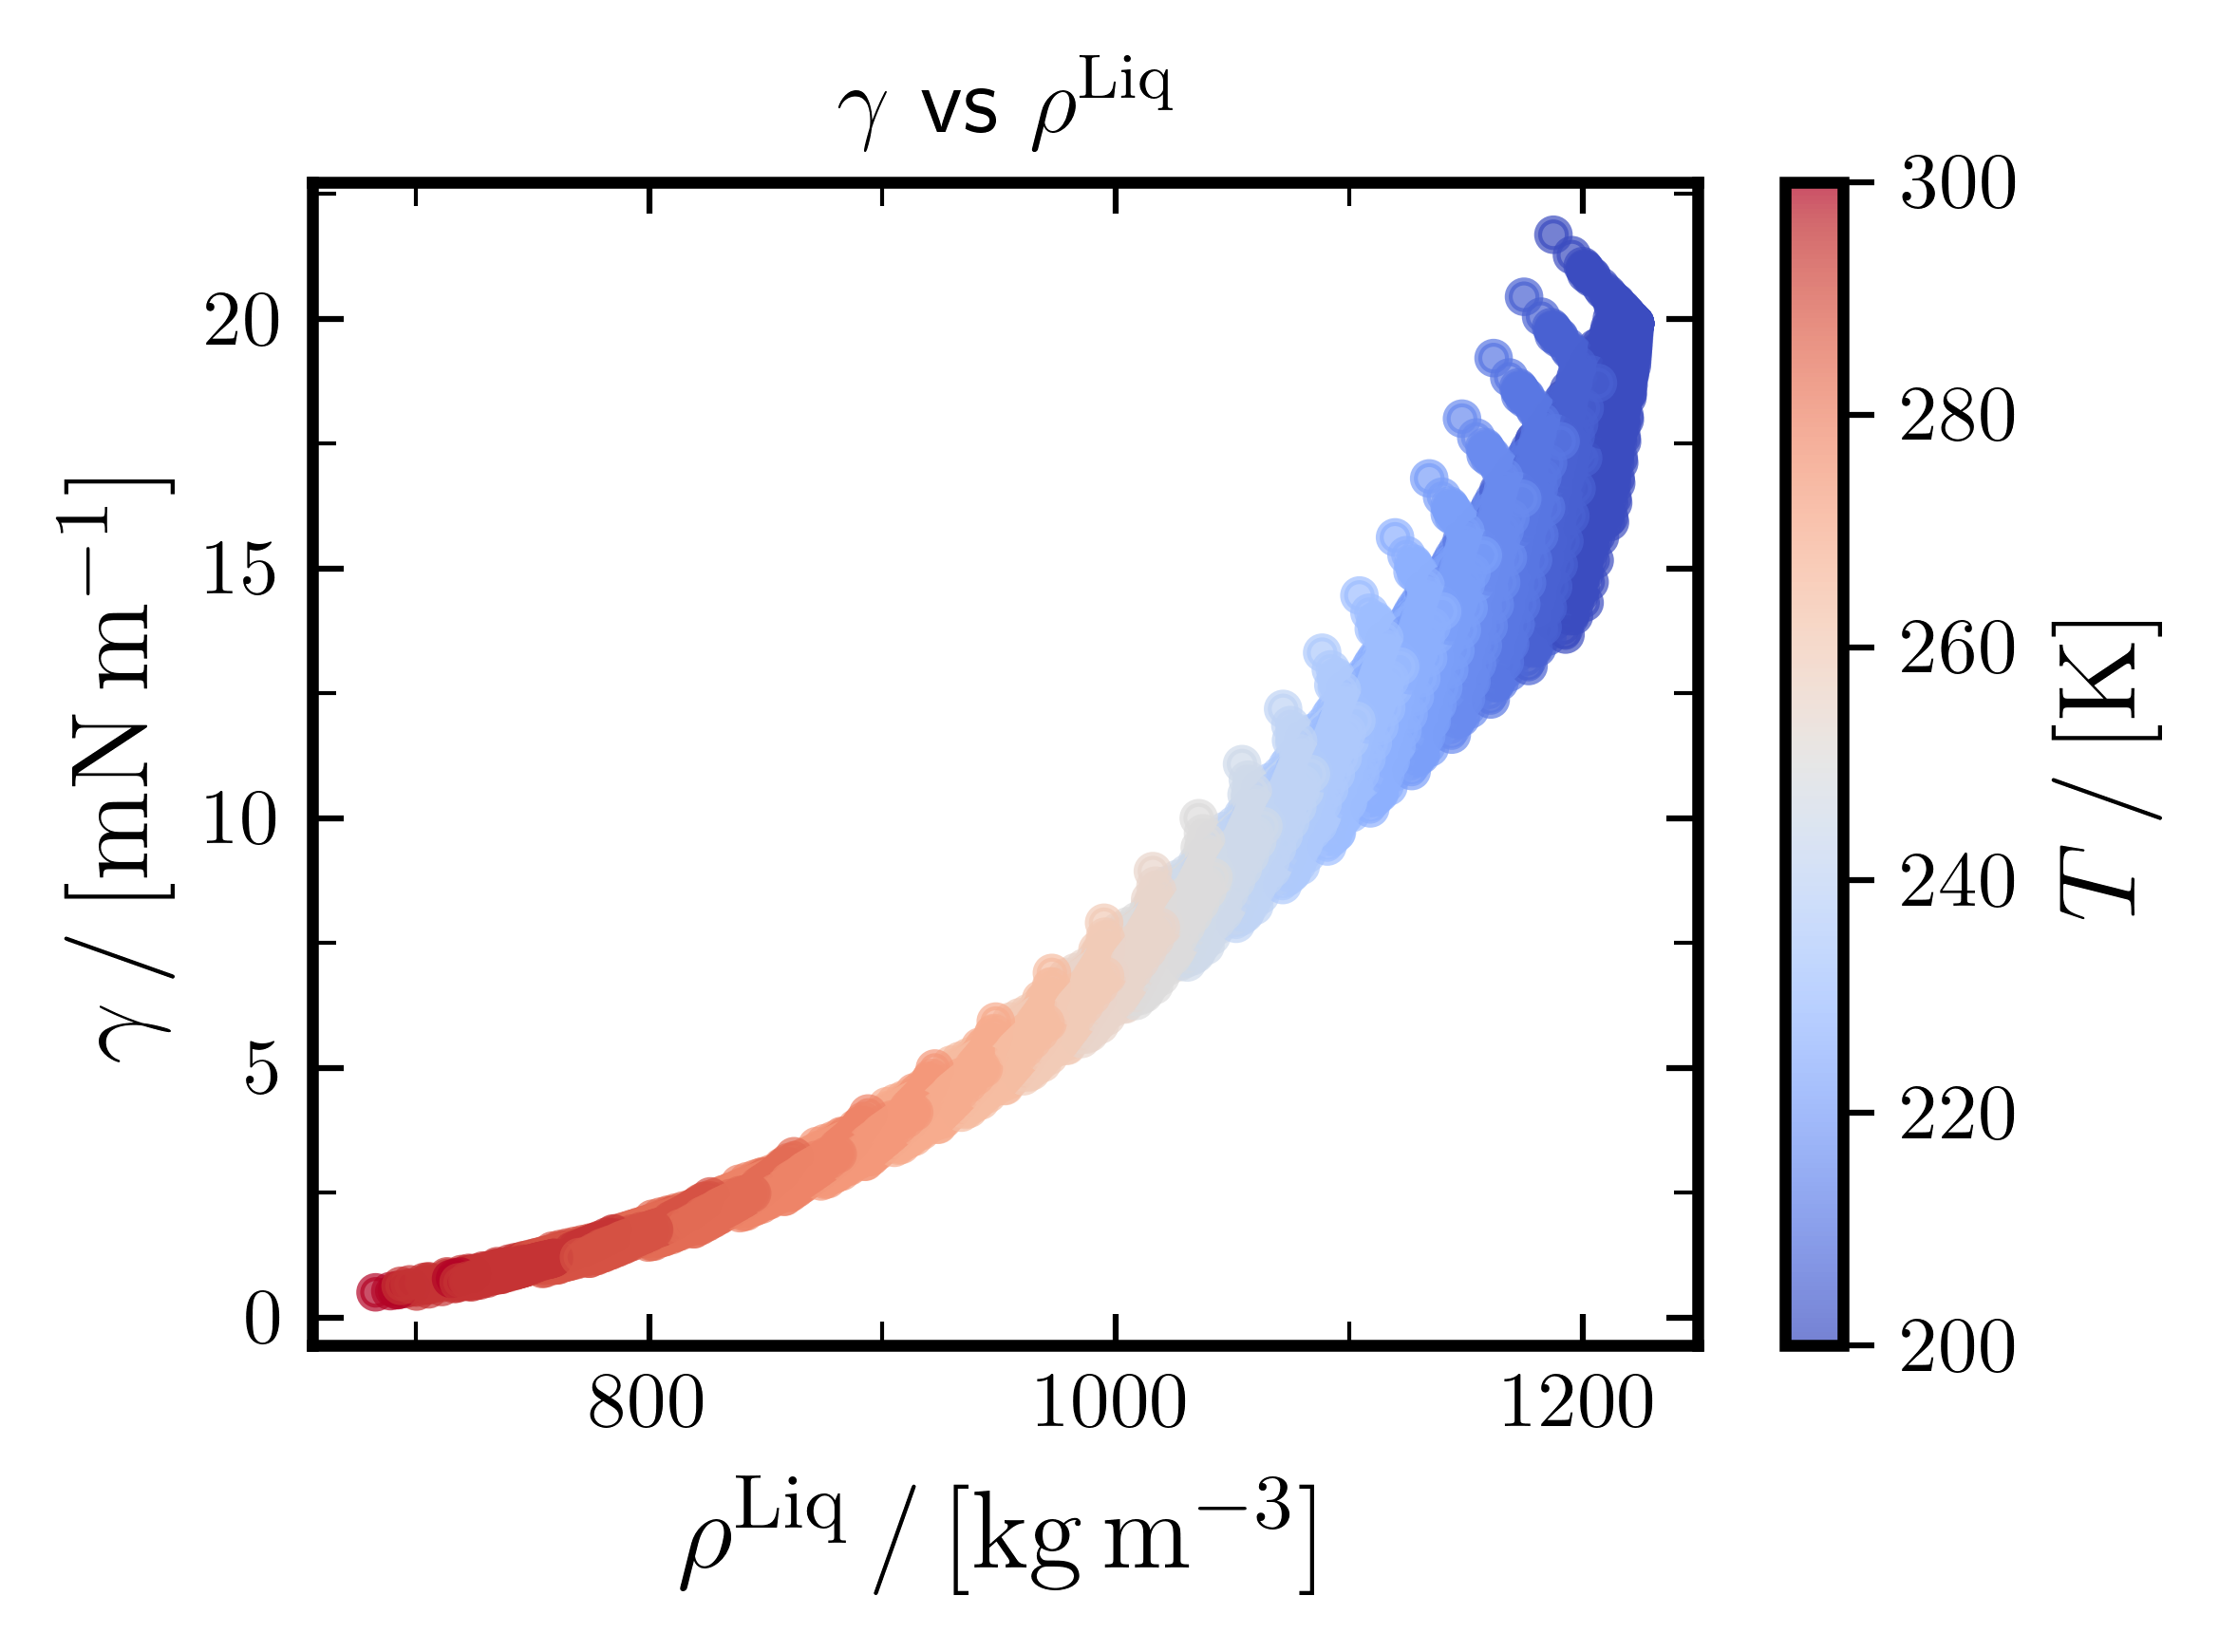

In [8]:
# 4. gamma vs Liquid Density
fig, ax = ps.plot_init()
sc = ax.scatter(combined_df["liquid_density"], combined_df["gamma"], c=combined_df["temperature"], cmap=ps.map, s=15, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize)
ps.style_colorbar(cbar)
ax.set_xlabel(r"$\rho^{\mathrm{Liq}}\, / \, [\mathrm{kg\,m^{-3}}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_title(r"$\gamma$ vs $\rho^{\mathrm{Liq}}$", fontsize=ps.title_fontsize, fontweight="bold")
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)
plt.tight_layout()
ps.save_plot(fig, "gamma_vs_rhoL")
plt.show()

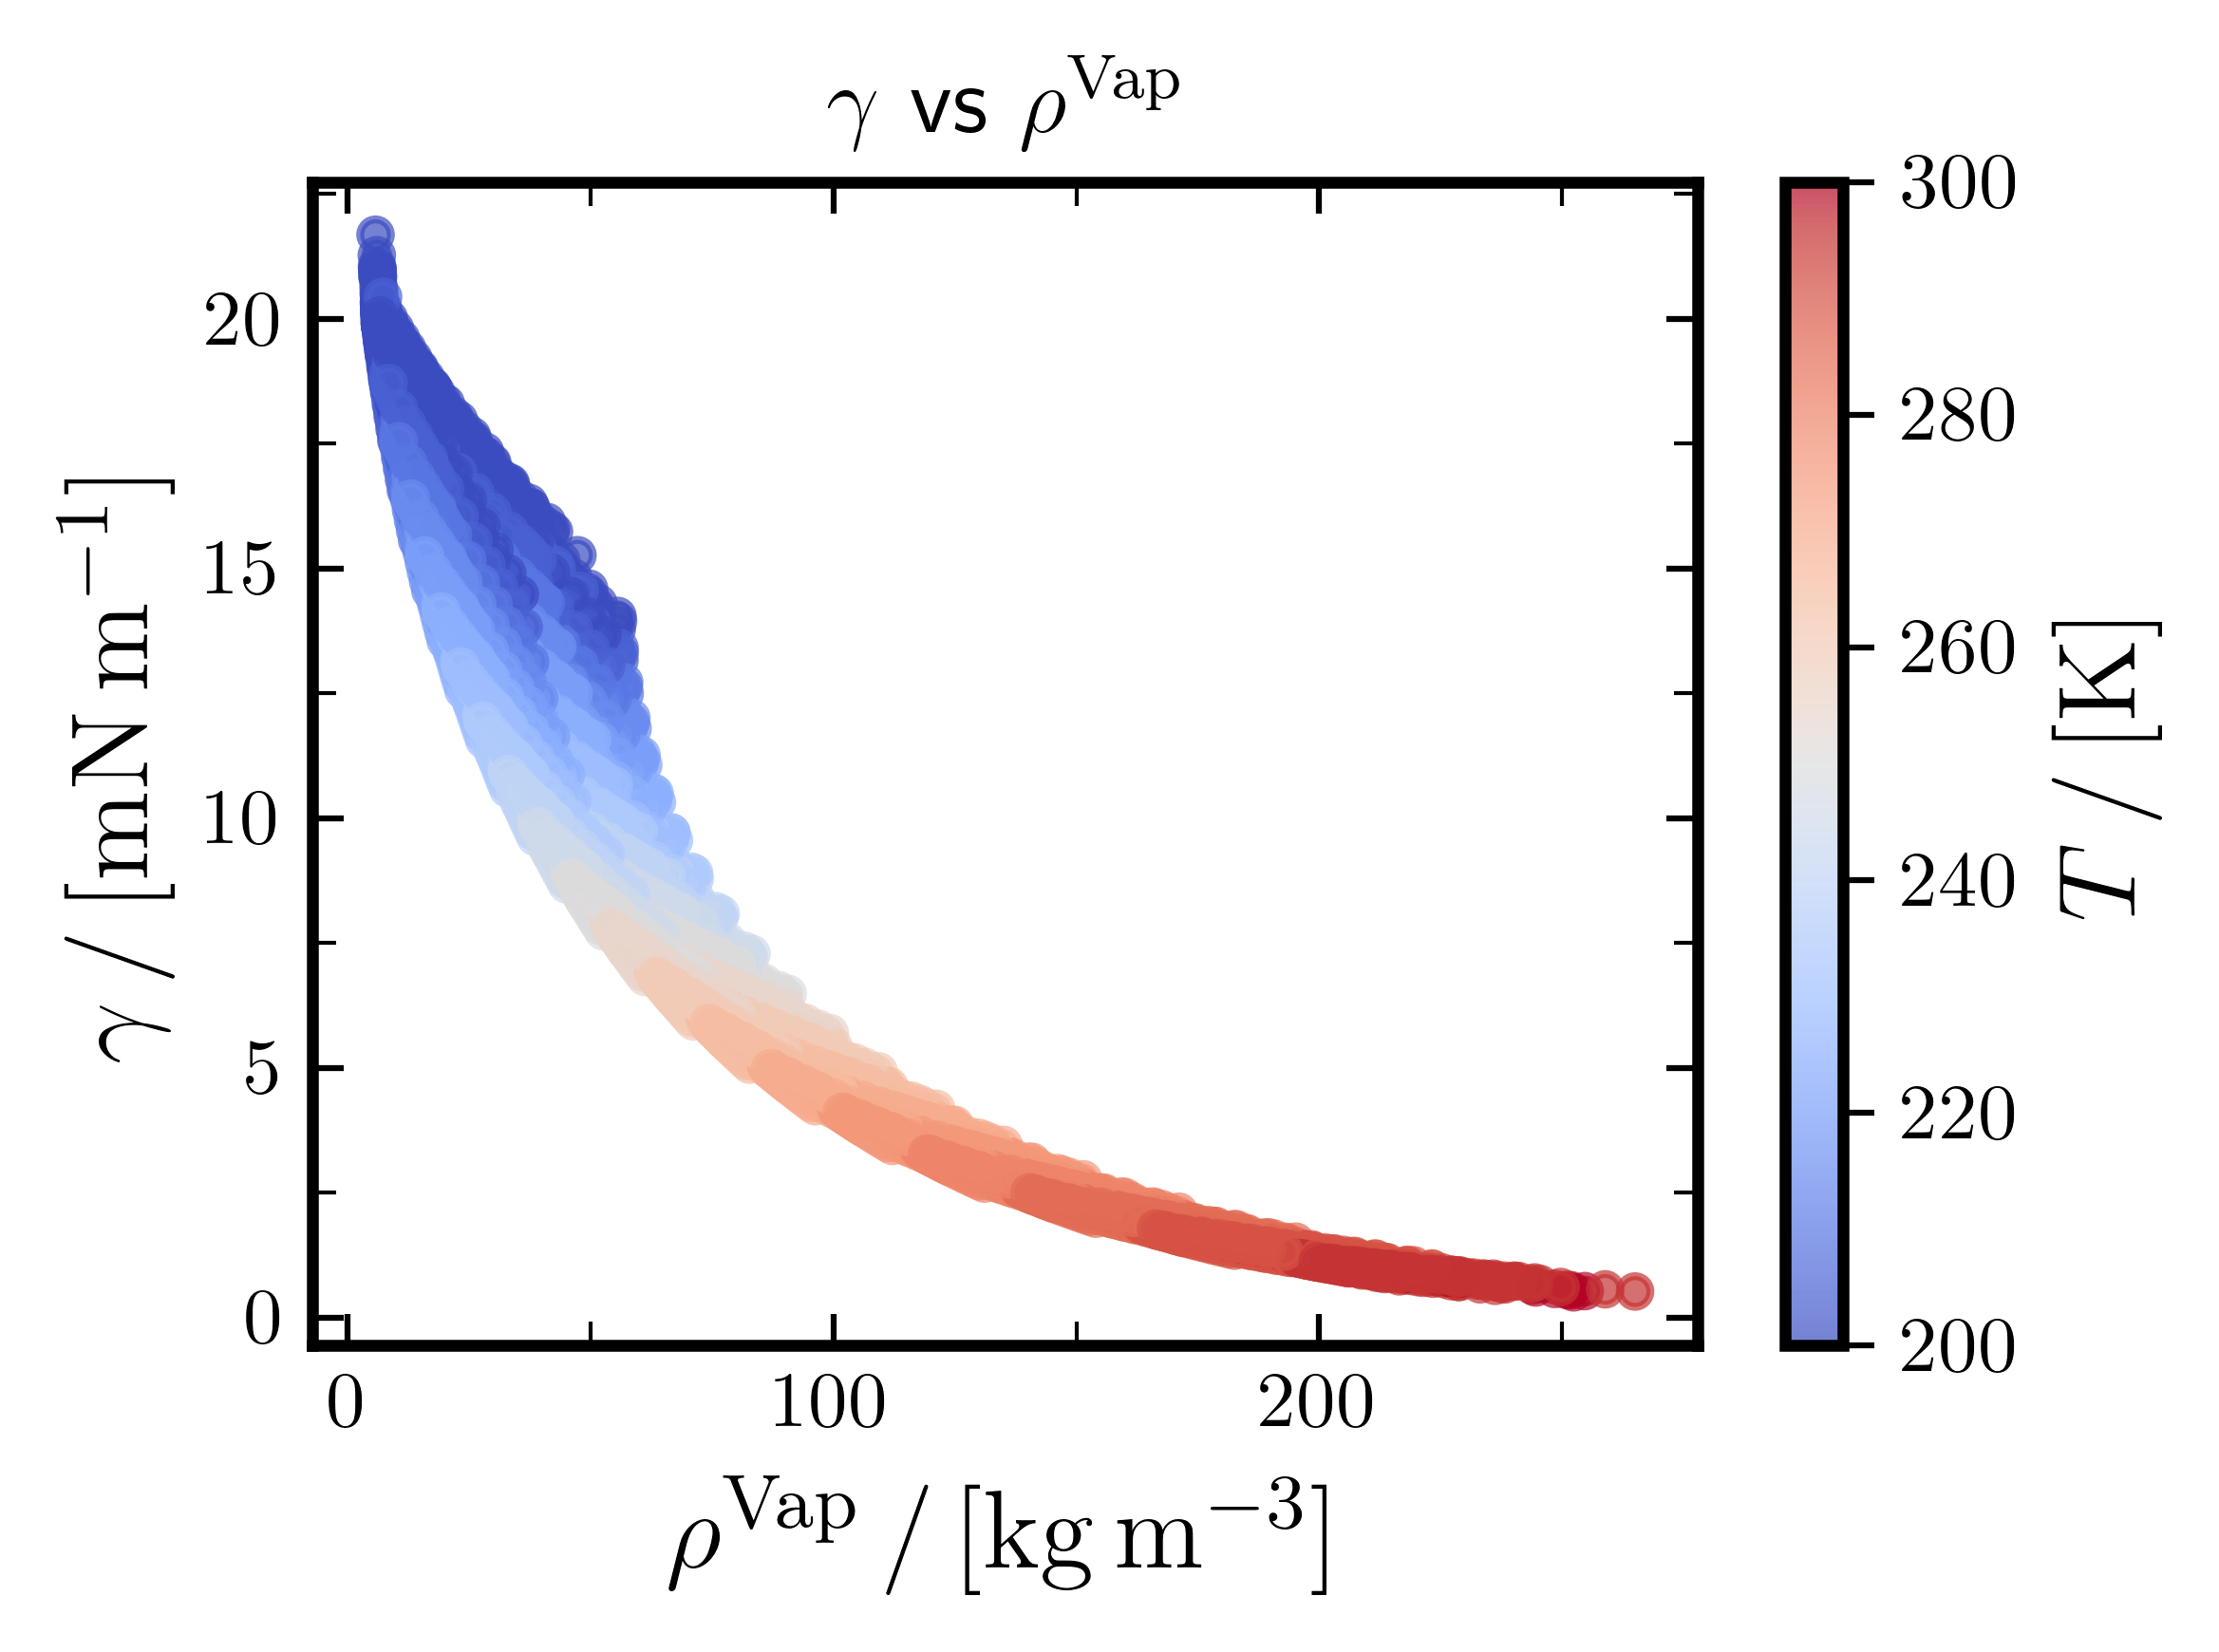

In [9]:
# 5. gamma vs Vapor Density
fig, ax = ps.plot_init()
sc = ax.scatter(combined_df["vapor_density"], combined_df["gamma"], c=combined_df["temperature"], cmap=ps.map, s=15, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize)
ps.style_colorbar(cbar)
ax.set_xlabel(r"$\rho^{\mathrm{Vap}}\, / \, [\mathrm{kg\,m^{-3}}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_title(r"$\gamma$ vs $\rho^{\mathrm{Vap}}$", fontsize=ps.title_fontsize, fontweight="bold")
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)
plt.tight_layout()
ps.save_plot(fig, "gamma_vs_rhoV")
plt.show()

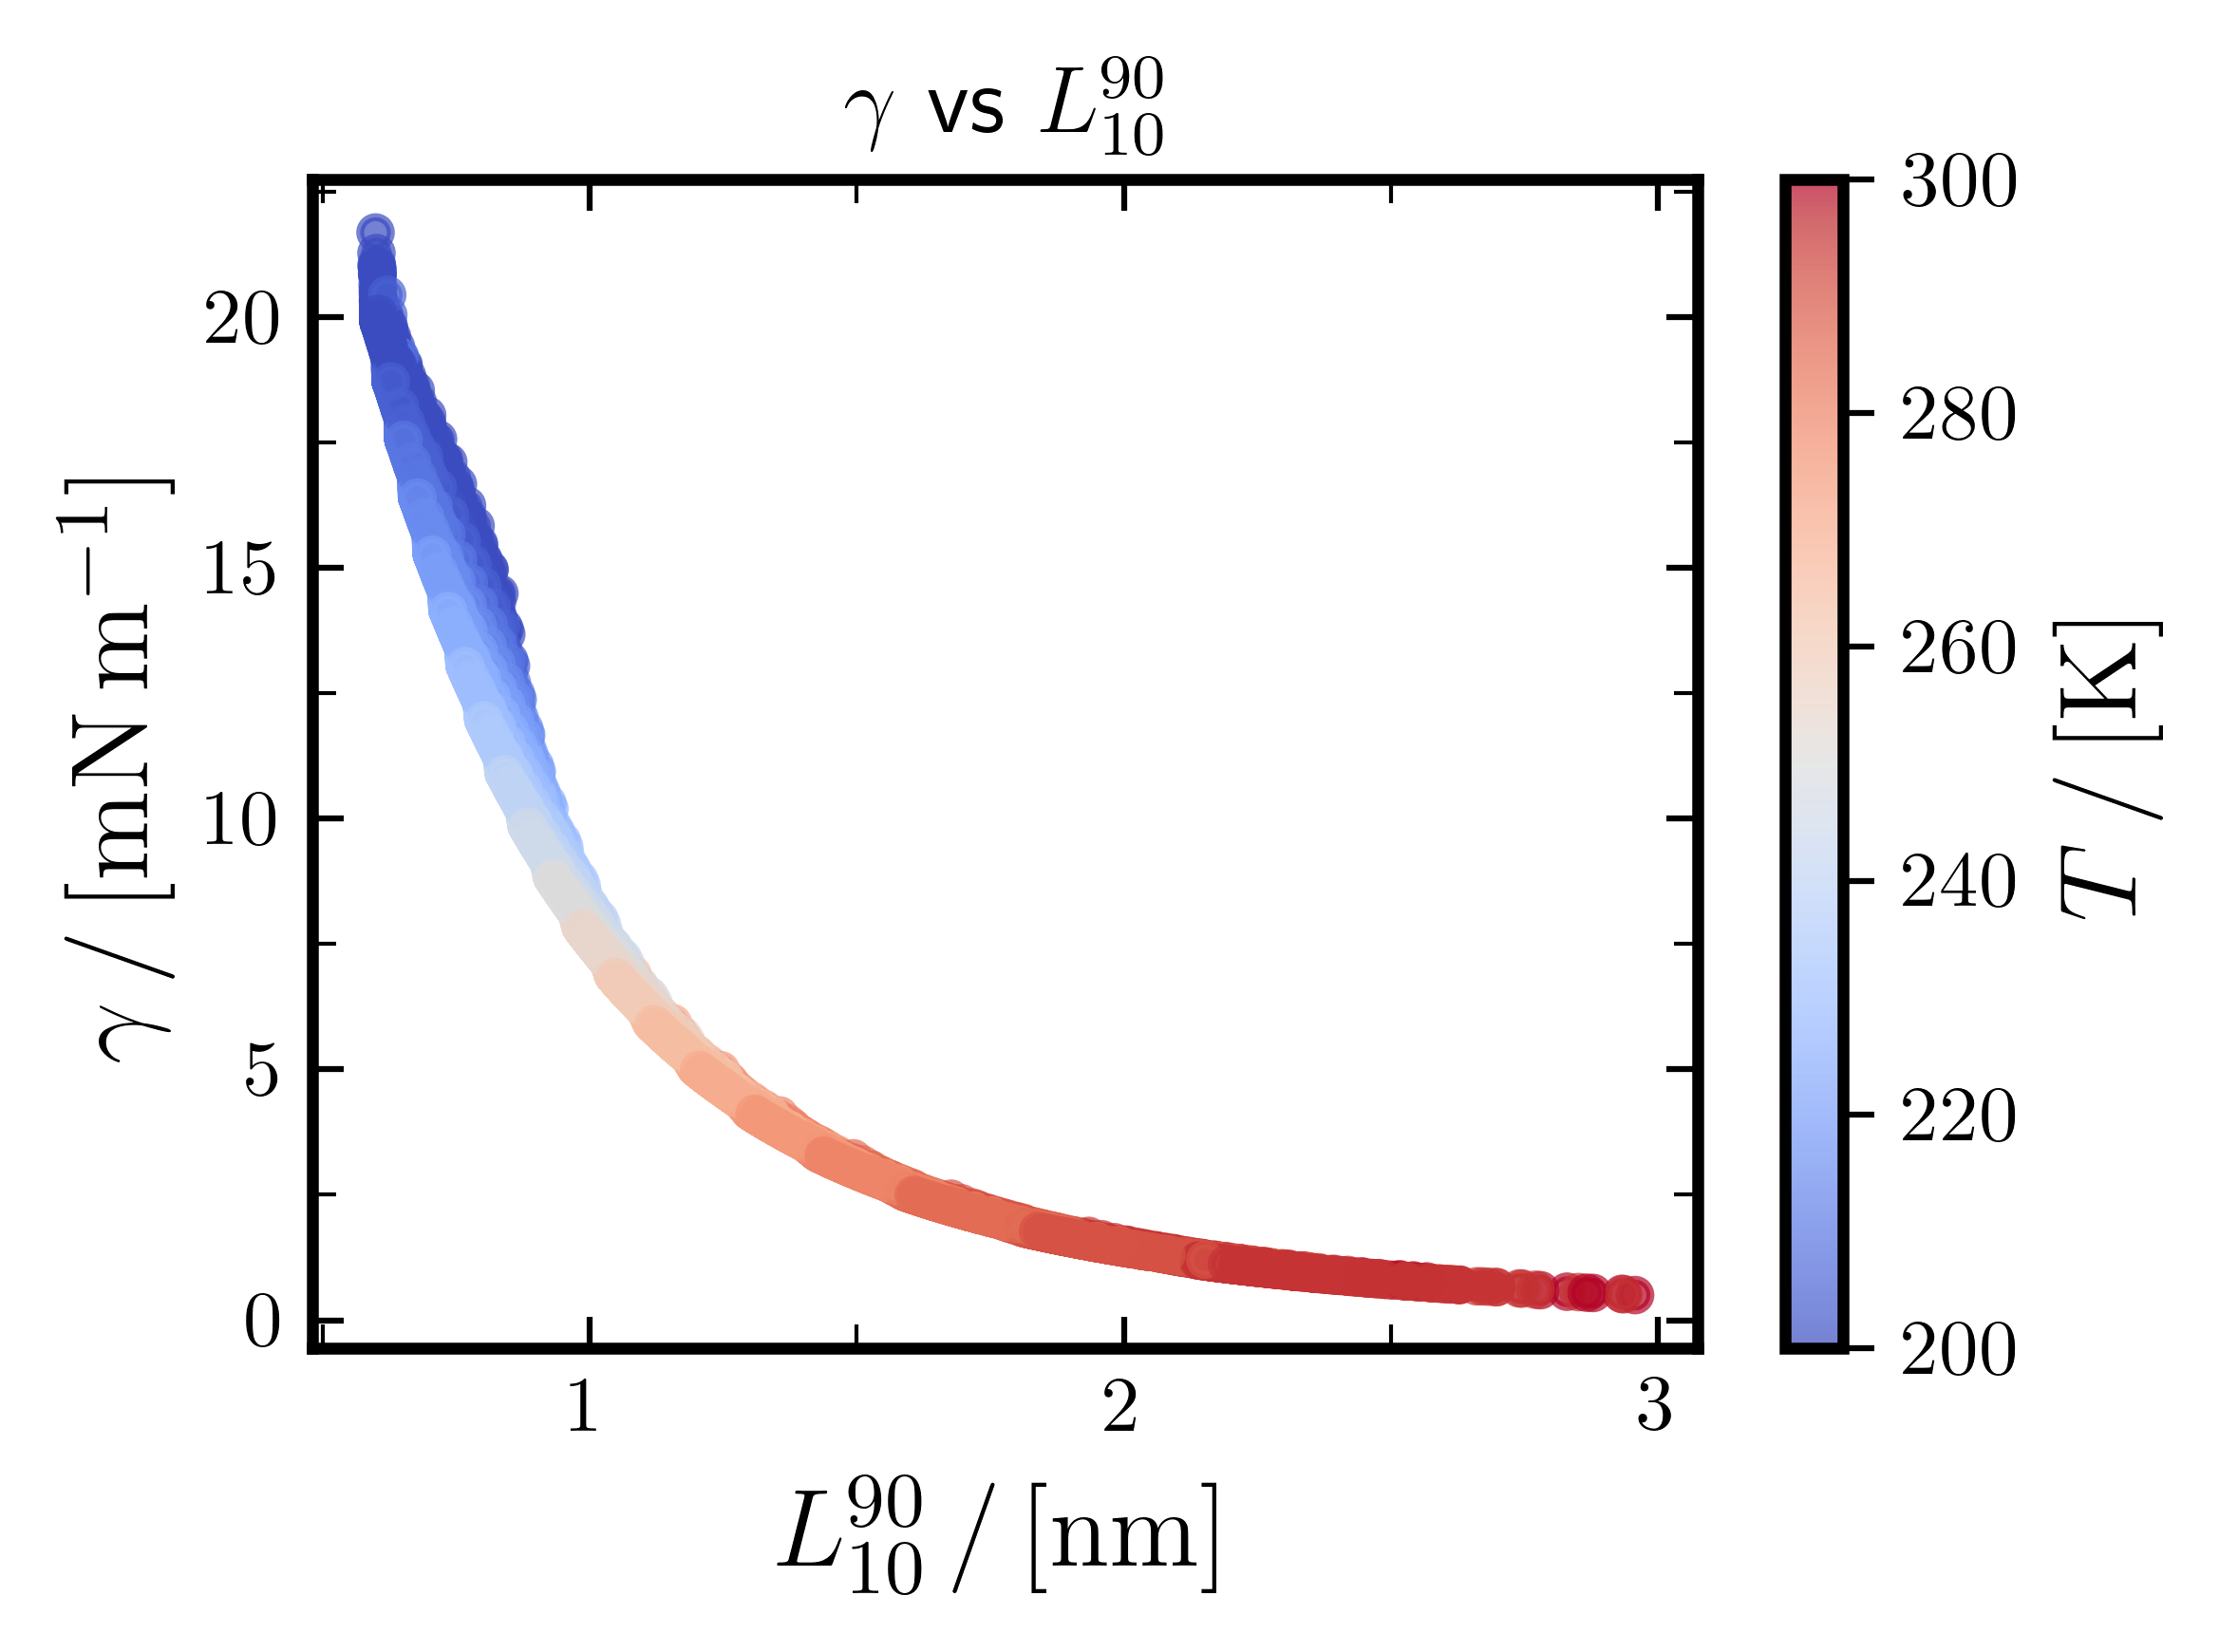

In [10]:
# 6. gamma vs Interfacial Thickness
fig, ax = ps.plot_init()
sc = ax.scatter(combined_df["interfacial_thickness"], combined_df["gamma"], c=combined_df["temperature"], cmap=ps.map, s=15, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize)
ps.style_colorbar(cbar)
ax.set_xlabel(r"$L_{10}^{90}\, / \, [\mathrm{nm}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_title(r"$\gamma$ vs $L_{10}^{90}$", fontsize=ps.title_fontsize, fontweight="bold")
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)
plt.tight_layout()
ps.save_plot(fig, "gamma_vs_thickness")
plt.show()

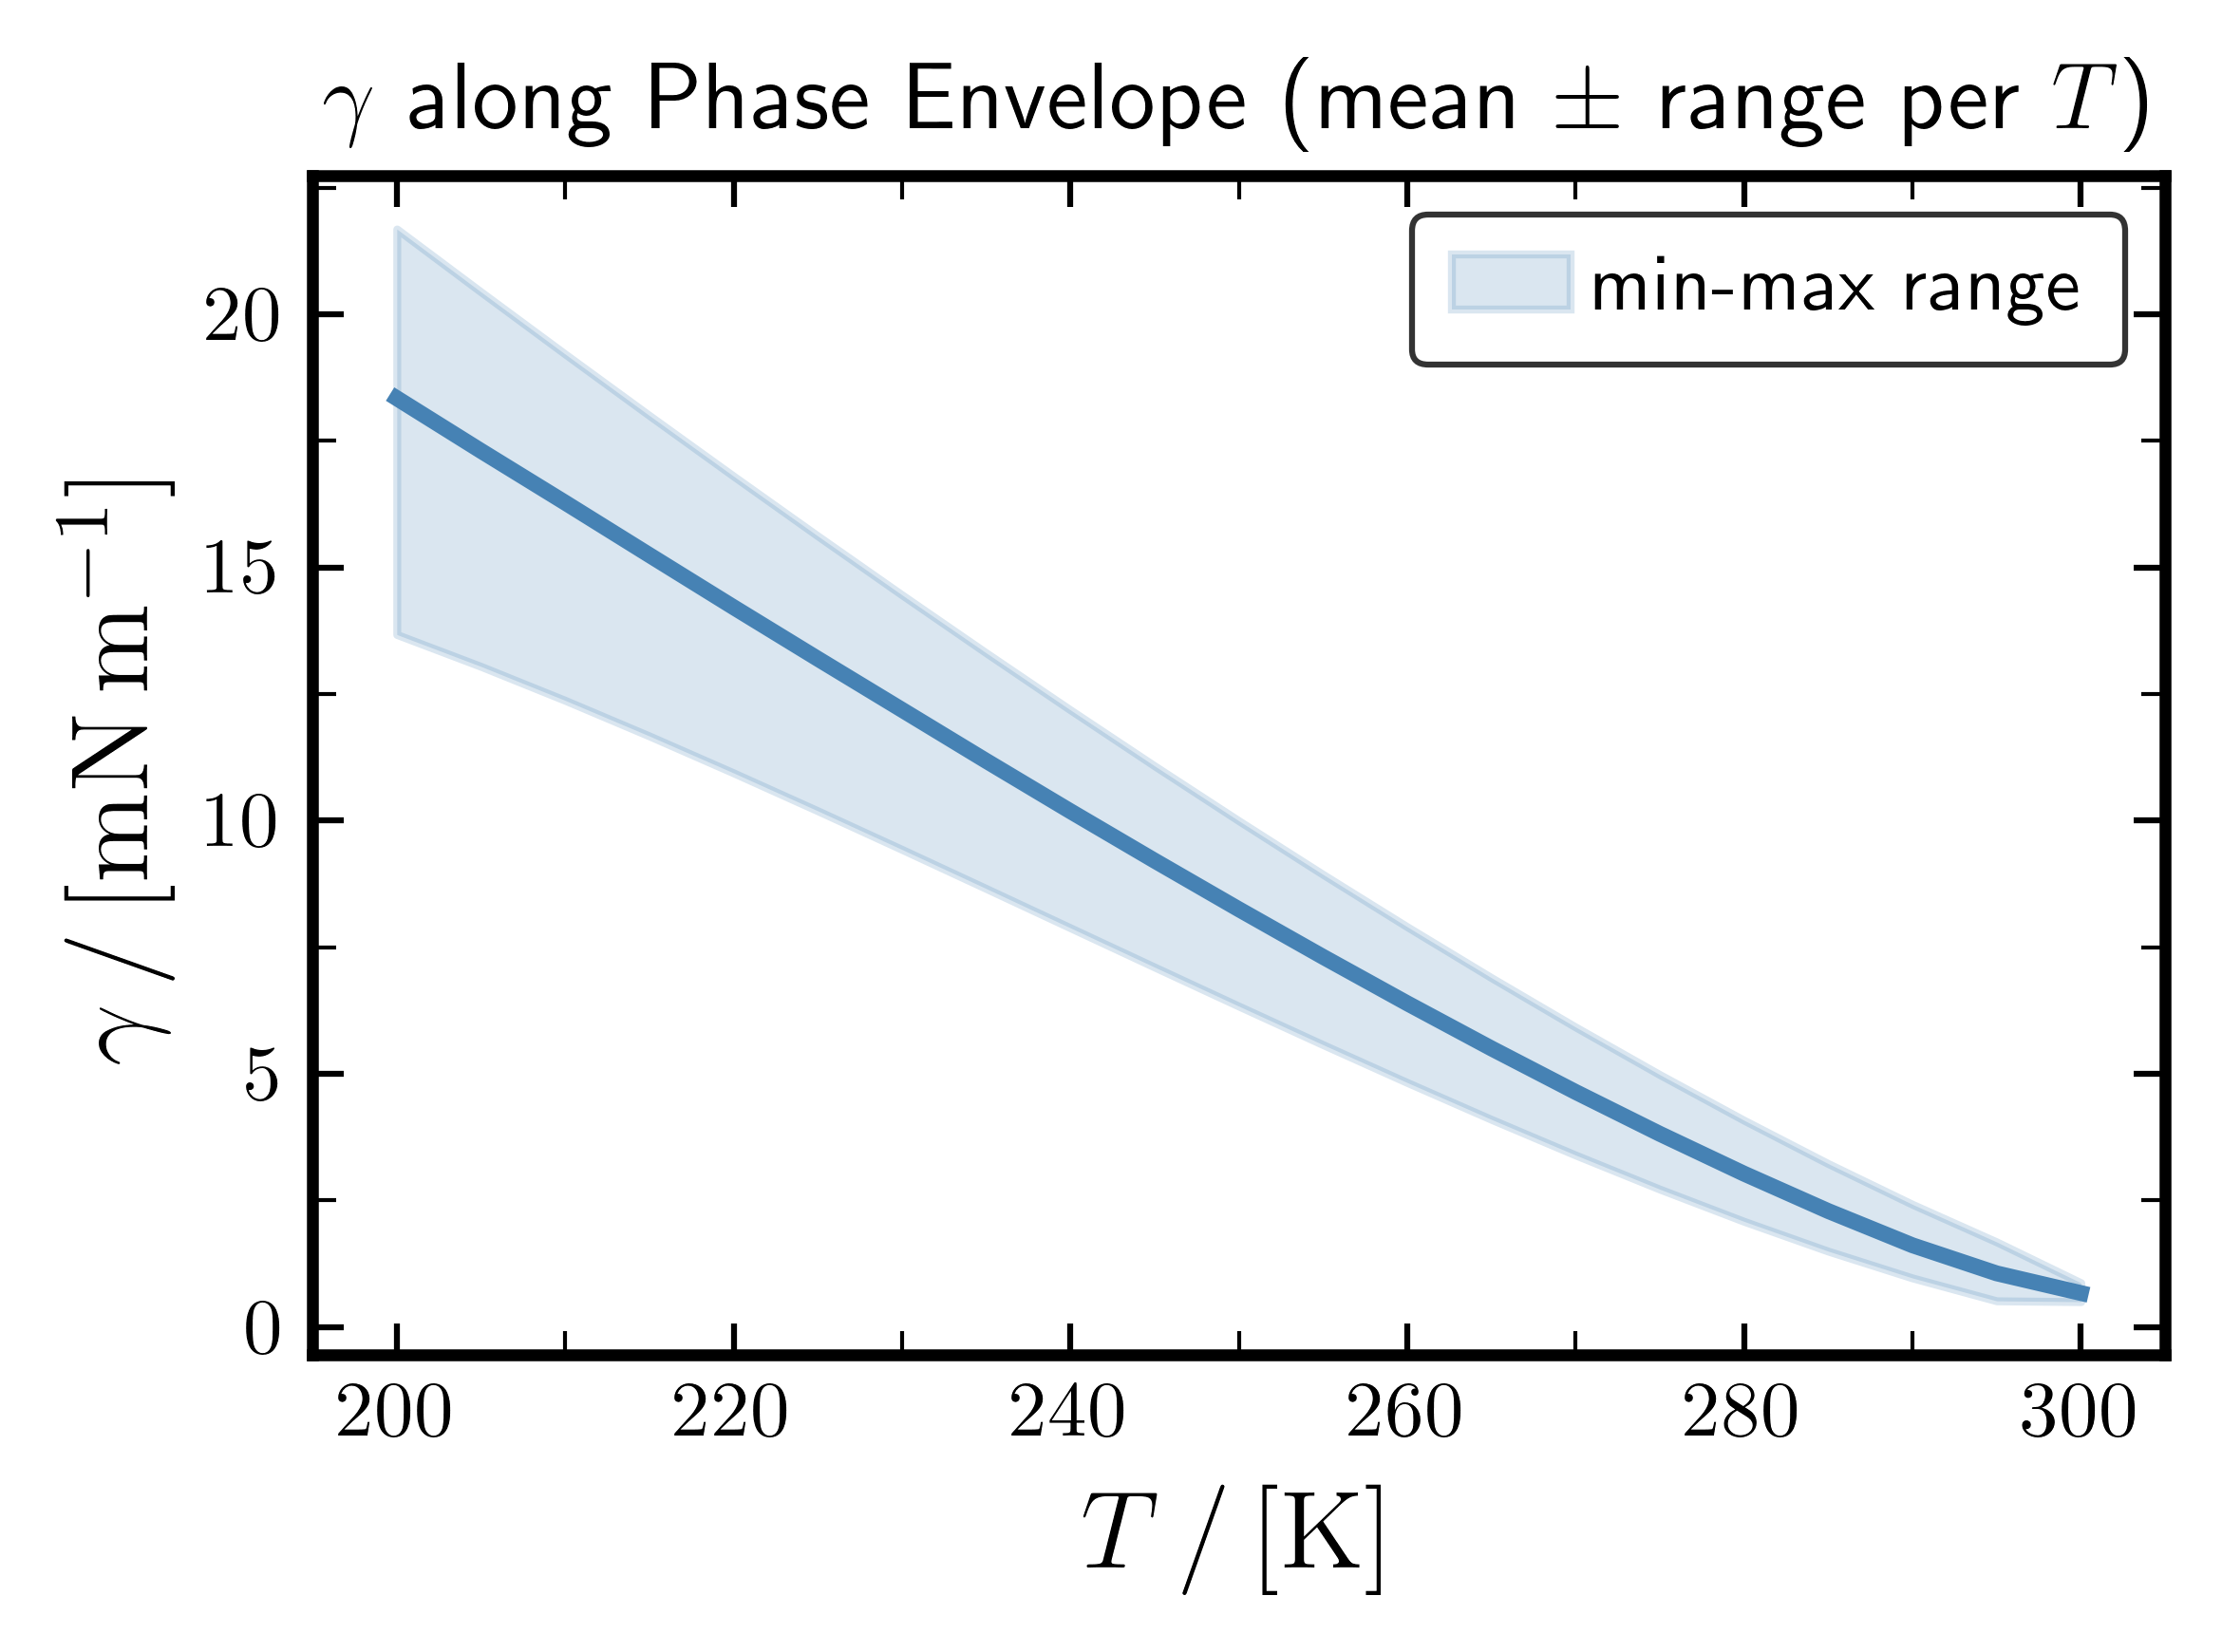

In [11]:
# 7. gamma along Phase Envelope (mean ± range per T)
fig, ax = ps.plot_init()
t_groups = combined_df.groupby("temperature")["gamma"]
t_vals = sorted(combined_df["temperature"].unique())
means = [t_groups.get_group(t).mean() for t in t_vals]
mins = [t_groups.get_group(t).min() for t in t_vals]
maxs = [t_groups.get_group(t).max() for t in t_vals]

ax.plot(t_vals, means, color="steelblue", linewidth=2)
ax.fill_between(t_vals, mins, maxs, alpha=0.2, color="steelblue", label=r"min-max range")
ax.set_xlabel(r"$T\, / \, [\mathrm{K}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma\, / \, [\mathrm{mN\,m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_title(r"$\gamma$ along Phase Envelope (mean $\pm$ range per $T$)", fontsize=ps.title_fontsize, fontweight="bold")
ps.apply_axis_style(ax)
ps.style_legend(ax, fontsize=max(getattr(ps, "legend_fontsize", 10), 10))
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)
plt.tight_layout()
ps.save_plot(fig, "gamma_phase_envelope")
plt.show()

In [12]:
# RANDOM FOREST REGRESSOR FEATURE IMPORTANCE
X = combined_df[feature_cols]
y = combined_df["gamma"]

model = RandomForestRegressor(random_state=45004)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=feature_cols)
print(importance.sort_values(ascending=False))
importance.index = [label_map.get(col, col) for col in importance.index]

temperature           0.976444
pressure              0.019824
z_hydrogen            0.001263
z_carbon dioxide      0.001026
z_methane             0.000535
z_carbon monoxide     0.000400
z_hydrogen sulfide    0.000246
z_nitrogen            0.000130
z_argon               0.000080
z_oxygen              0.000053
dtype: float64


In [13]:
# Calculate RMSE and R2 on test set
y_pred_test = model.predict(X_test[feature_cols])
y_pred_train = model.predict(X_train[feature_cols])

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print("=" * 60)
print("RANDOM FOREST MODEL PERFORMANCE")
print("=" * 60)
print(f"Training Set:")
print(f"  R2 Score:  {r2_train:.6f}")
print(f"  RMSE:      {rmse_train:.6f}")
print(f"\nTest Set:")
print(f"  R2 Score:  {r2_test:.6f}")
print(f"  RMSE:      {rmse_test:.6f}")
print("=" * 60)

RANDOM FOREST MODEL PERFORMANCE
Training Set:
  R2 Score:  0.999951
  RMSE:      0.037429

Test Set:
  R2 Score:  0.999951
  RMSE:      0.037726


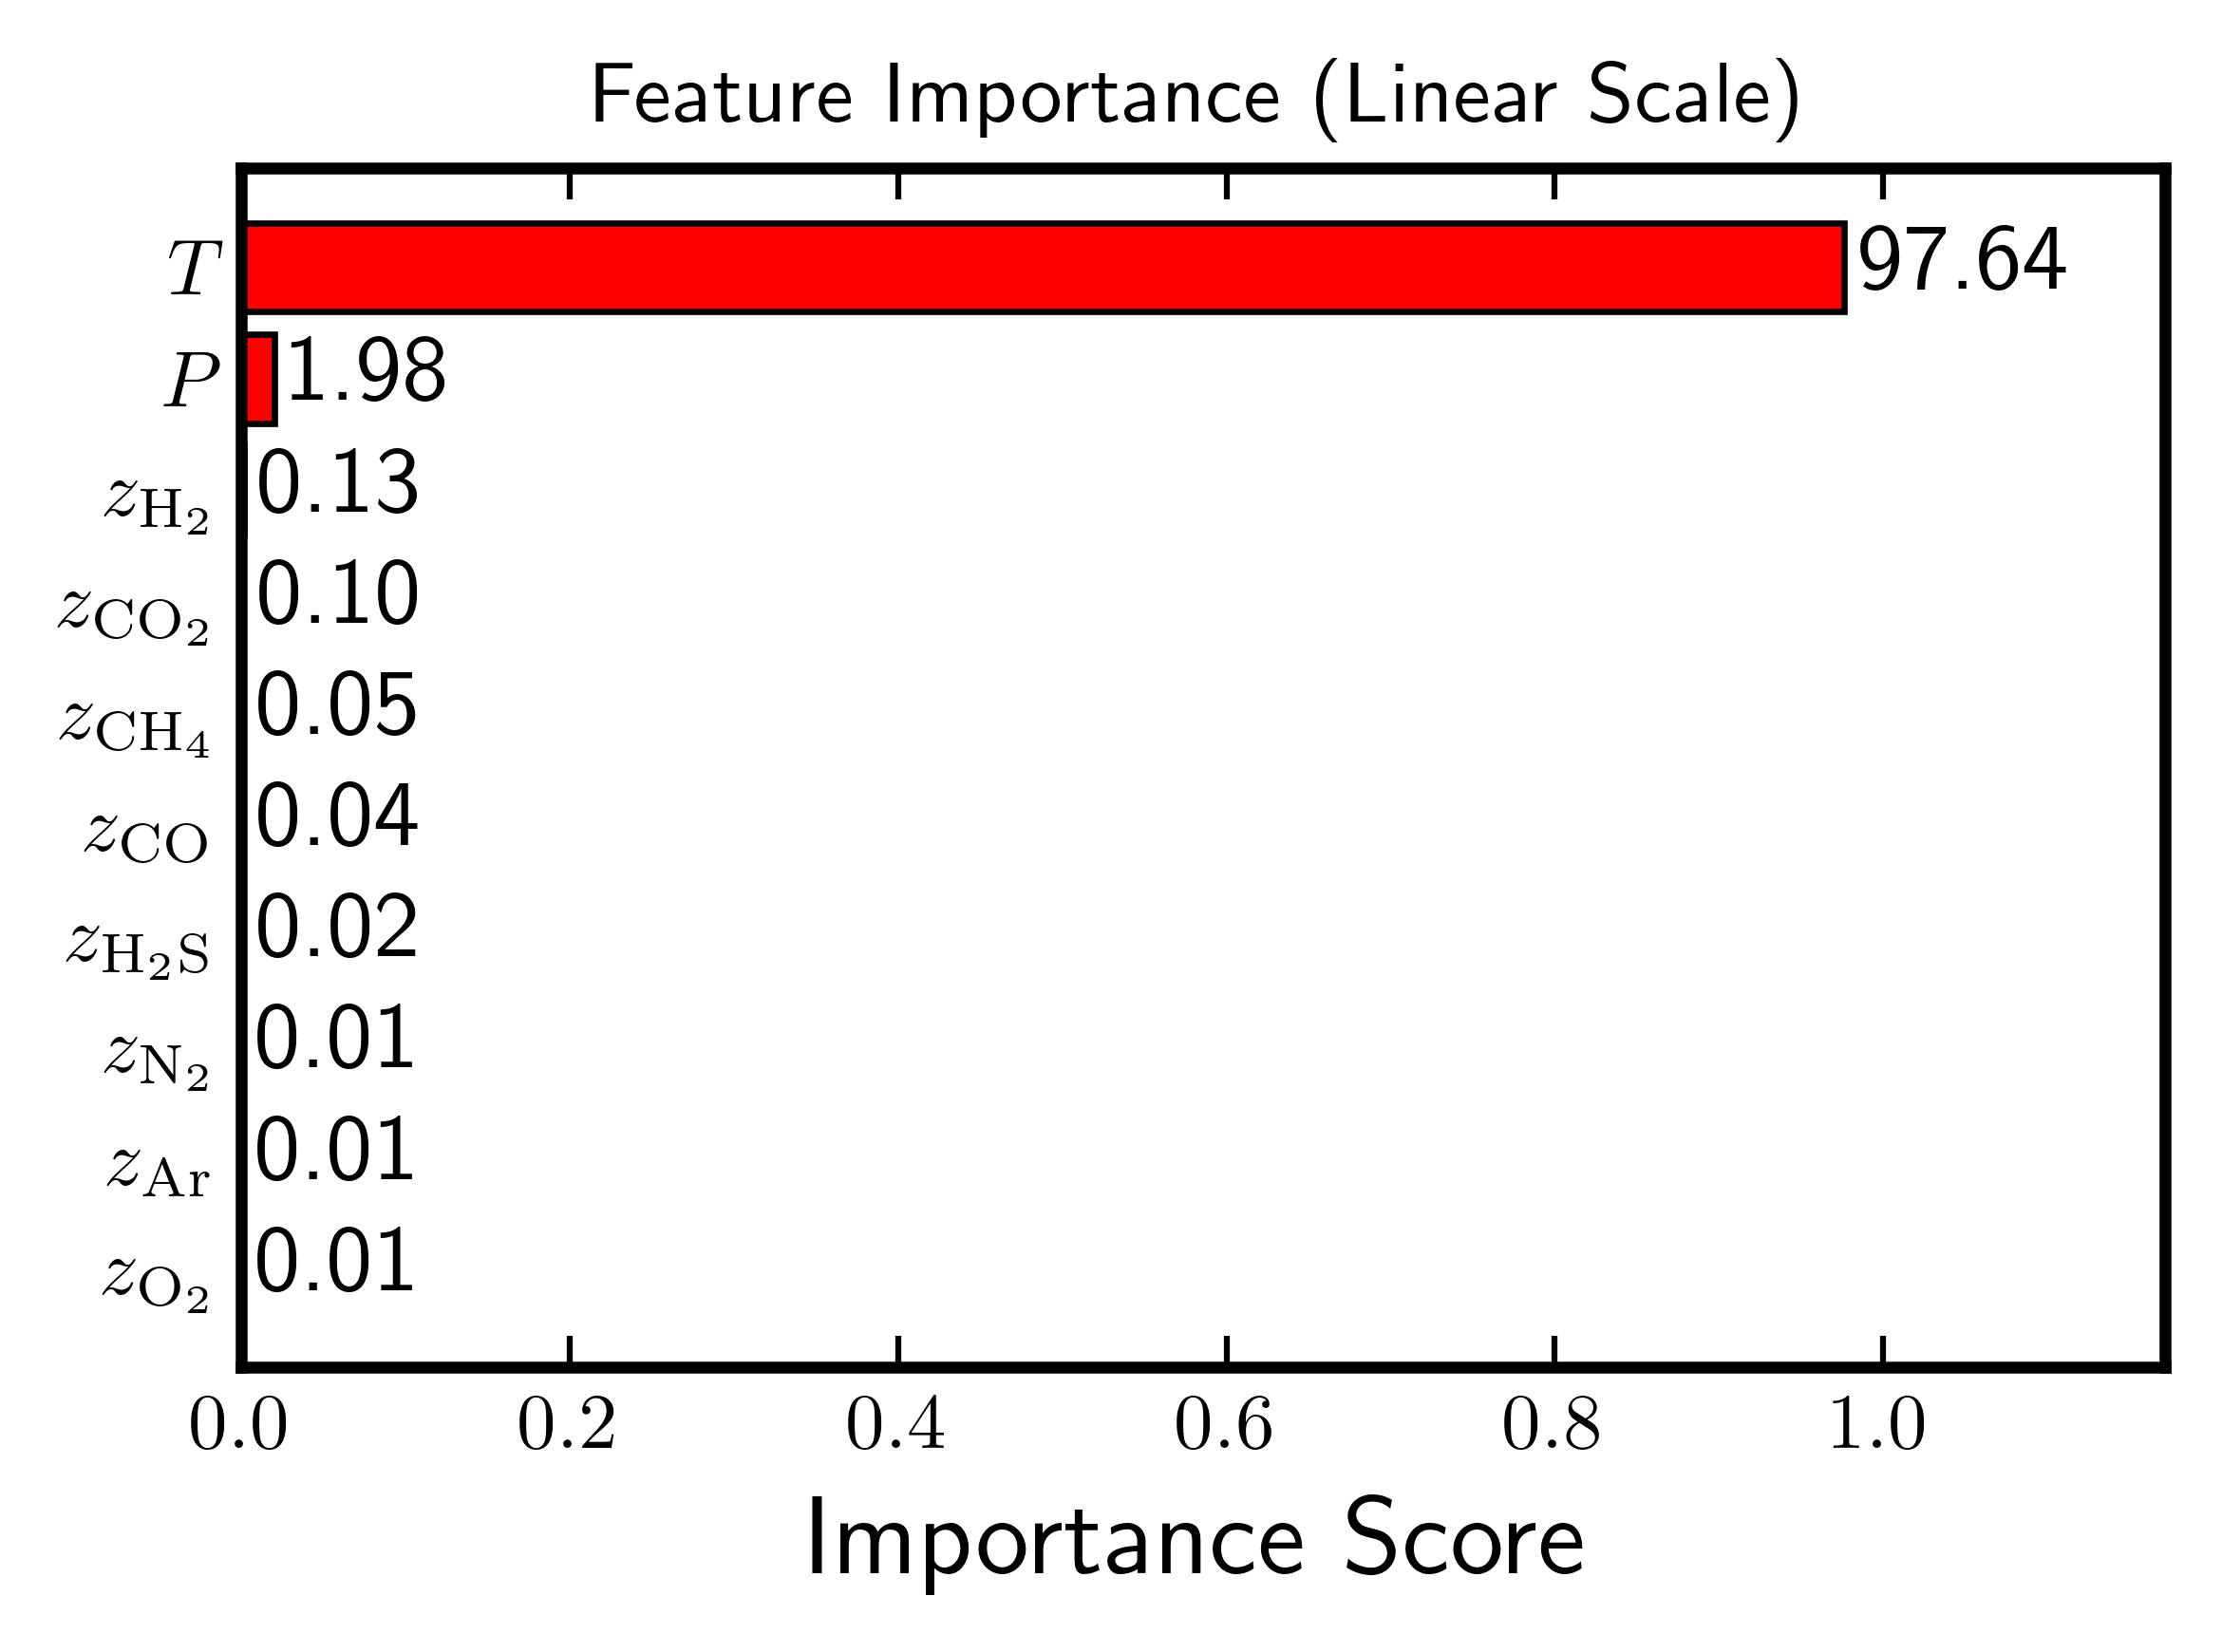

In [14]:
importance_sorted = importance.sort_values()
feat_names = [label_map.get(col, col) for col in importance_sorted.index]
imp_vals = importance_sorted.values
imp_percent = (imp_vals / imp_vals.sum()) * 100

# ==================== Linear Scale ====================
fig_lin, ax_lin = ps.plot_init()

bars_lin = ax_lin.barh(
    feat_names,
    imp_vals,
    color="red",
    edgecolor="black",
    linewidth=0.8
)

ax_lin.set_xlabel("Importance Score", fontsize=ps.label_fontsize)
ax_lin.set_title("Feature Importance (Linear Scale)", fontsize=ps.title_fontsize * 0.9, fontweight="bold")

for bar, val, pct in zip(bars_lin, imp_vals, imp_percent):
    ax_lin.text(
        val + 0.01 * imp_vals.max(),
        bar.get_y() + bar.get_height()/2,
        f"{pct:.2f}%",
        va="center",
        ha="left",
        fontsize=ps.label_fontsize * 0.85
    )

ax_lin.set_xlim(0, imp_vals.max() * 1.2)
ps.apply_axis_style(ax_lin)
ax_lin.tick_params(axis="y", length=0)

plt.tight_layout()
ps.save_plot(fig_lin, "feature_importance_linear")
plt.show()

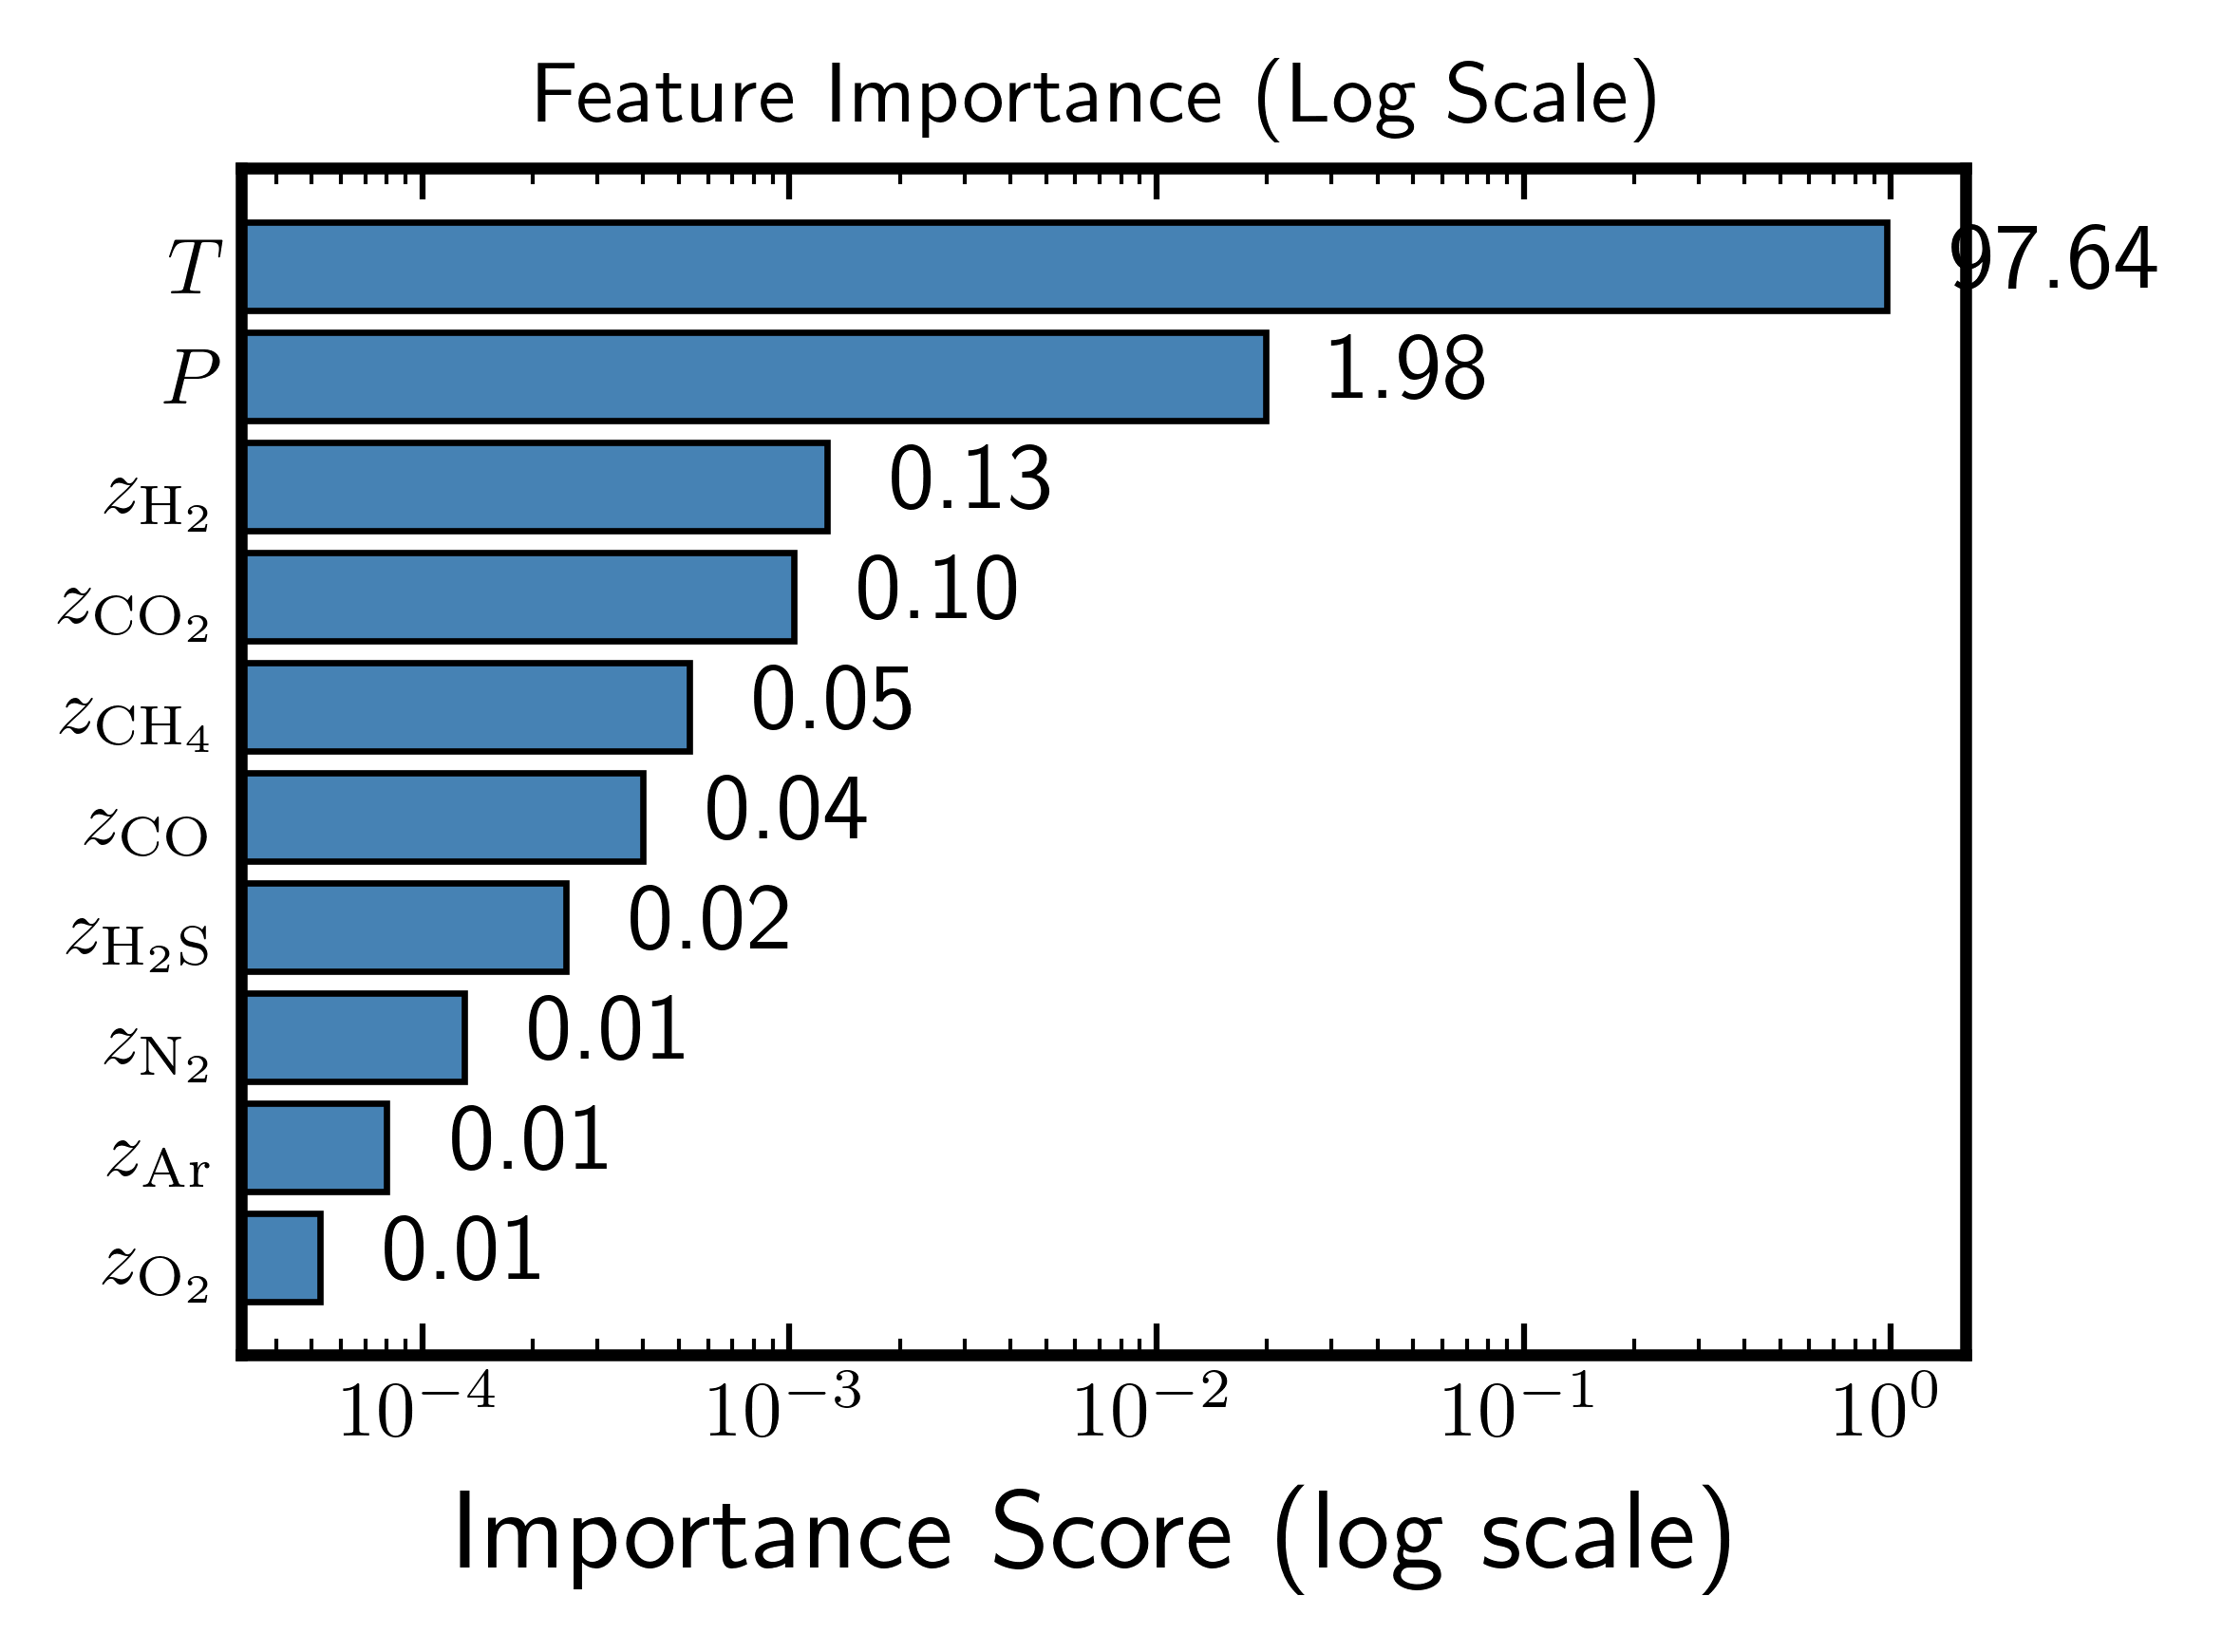


FEATURE IMPORTANCE ANALYSIS
$T$                  |  97.64% | ████████████████████████████████████████████████
$P$                  |   1.98% | 
$z_{\mathrm{H_2}}$   |   0.13% | 
$z_{\mathrm{CO_2}}$  |   0.10% | 
$z_{\mathrm{CH_4}}$  |   0.05% | 
$z_{\mathrm{CO}}$    |   0.04% | 
$z_{\mathrm{H_2S}}$  |   0.02% | 
$z_{\mathrm{N_2}}$   |   0.01% | 
$z_{\mathrm{Ar}}$    |   0.01% | 
$z_{\mathrm{O_2}}$   |   0.01% | 


In [15]:
# ==================== Log Scale ====================
fig_log, ax_log = ps.plot_init()

bars_log = ax_log.barh(
    feat_names,
    imp_vals,
    color="steelblue",
    edgecolor="black",
    linewidth=0.8
)

ax_log.set_xlabel("Importance Score (log scale)", fontsize=ps.label_fontsize)
ax_log.set_title("Feature Importance (Log Scale)", fontsize=ps.title_fontsize * 0.9, fontweight="bold")
ax_log.set_xscale("log")

for bar, val, pct in zip(bars_log, imp_vals, imp_percent):
    ax_log.text(
        val * 1.5,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.2f}%",
        va="center",
        ha="left",
        fontsize=ps.label_fontsize * 0.85
    )

ps.apply_axis_style(ax_log)
ax_log.tick_params(axis="y", length=0)

plt.tight_layout()
ps.save_plot(fig_log, "feature_importance_log")
plt.show()

# Print detailed summary
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)
for fname, val, pct in sorted(zip(feat_names, imp_vals, imp_percent), key=lambda x: x[2], reverse=True):
    bar_length = int(pct / 2)  # Scale bar to 50 chars max
    bar = "█" * bar_length
    print(f"{fname:20s} | {pct:6.2f}% | {bar}")

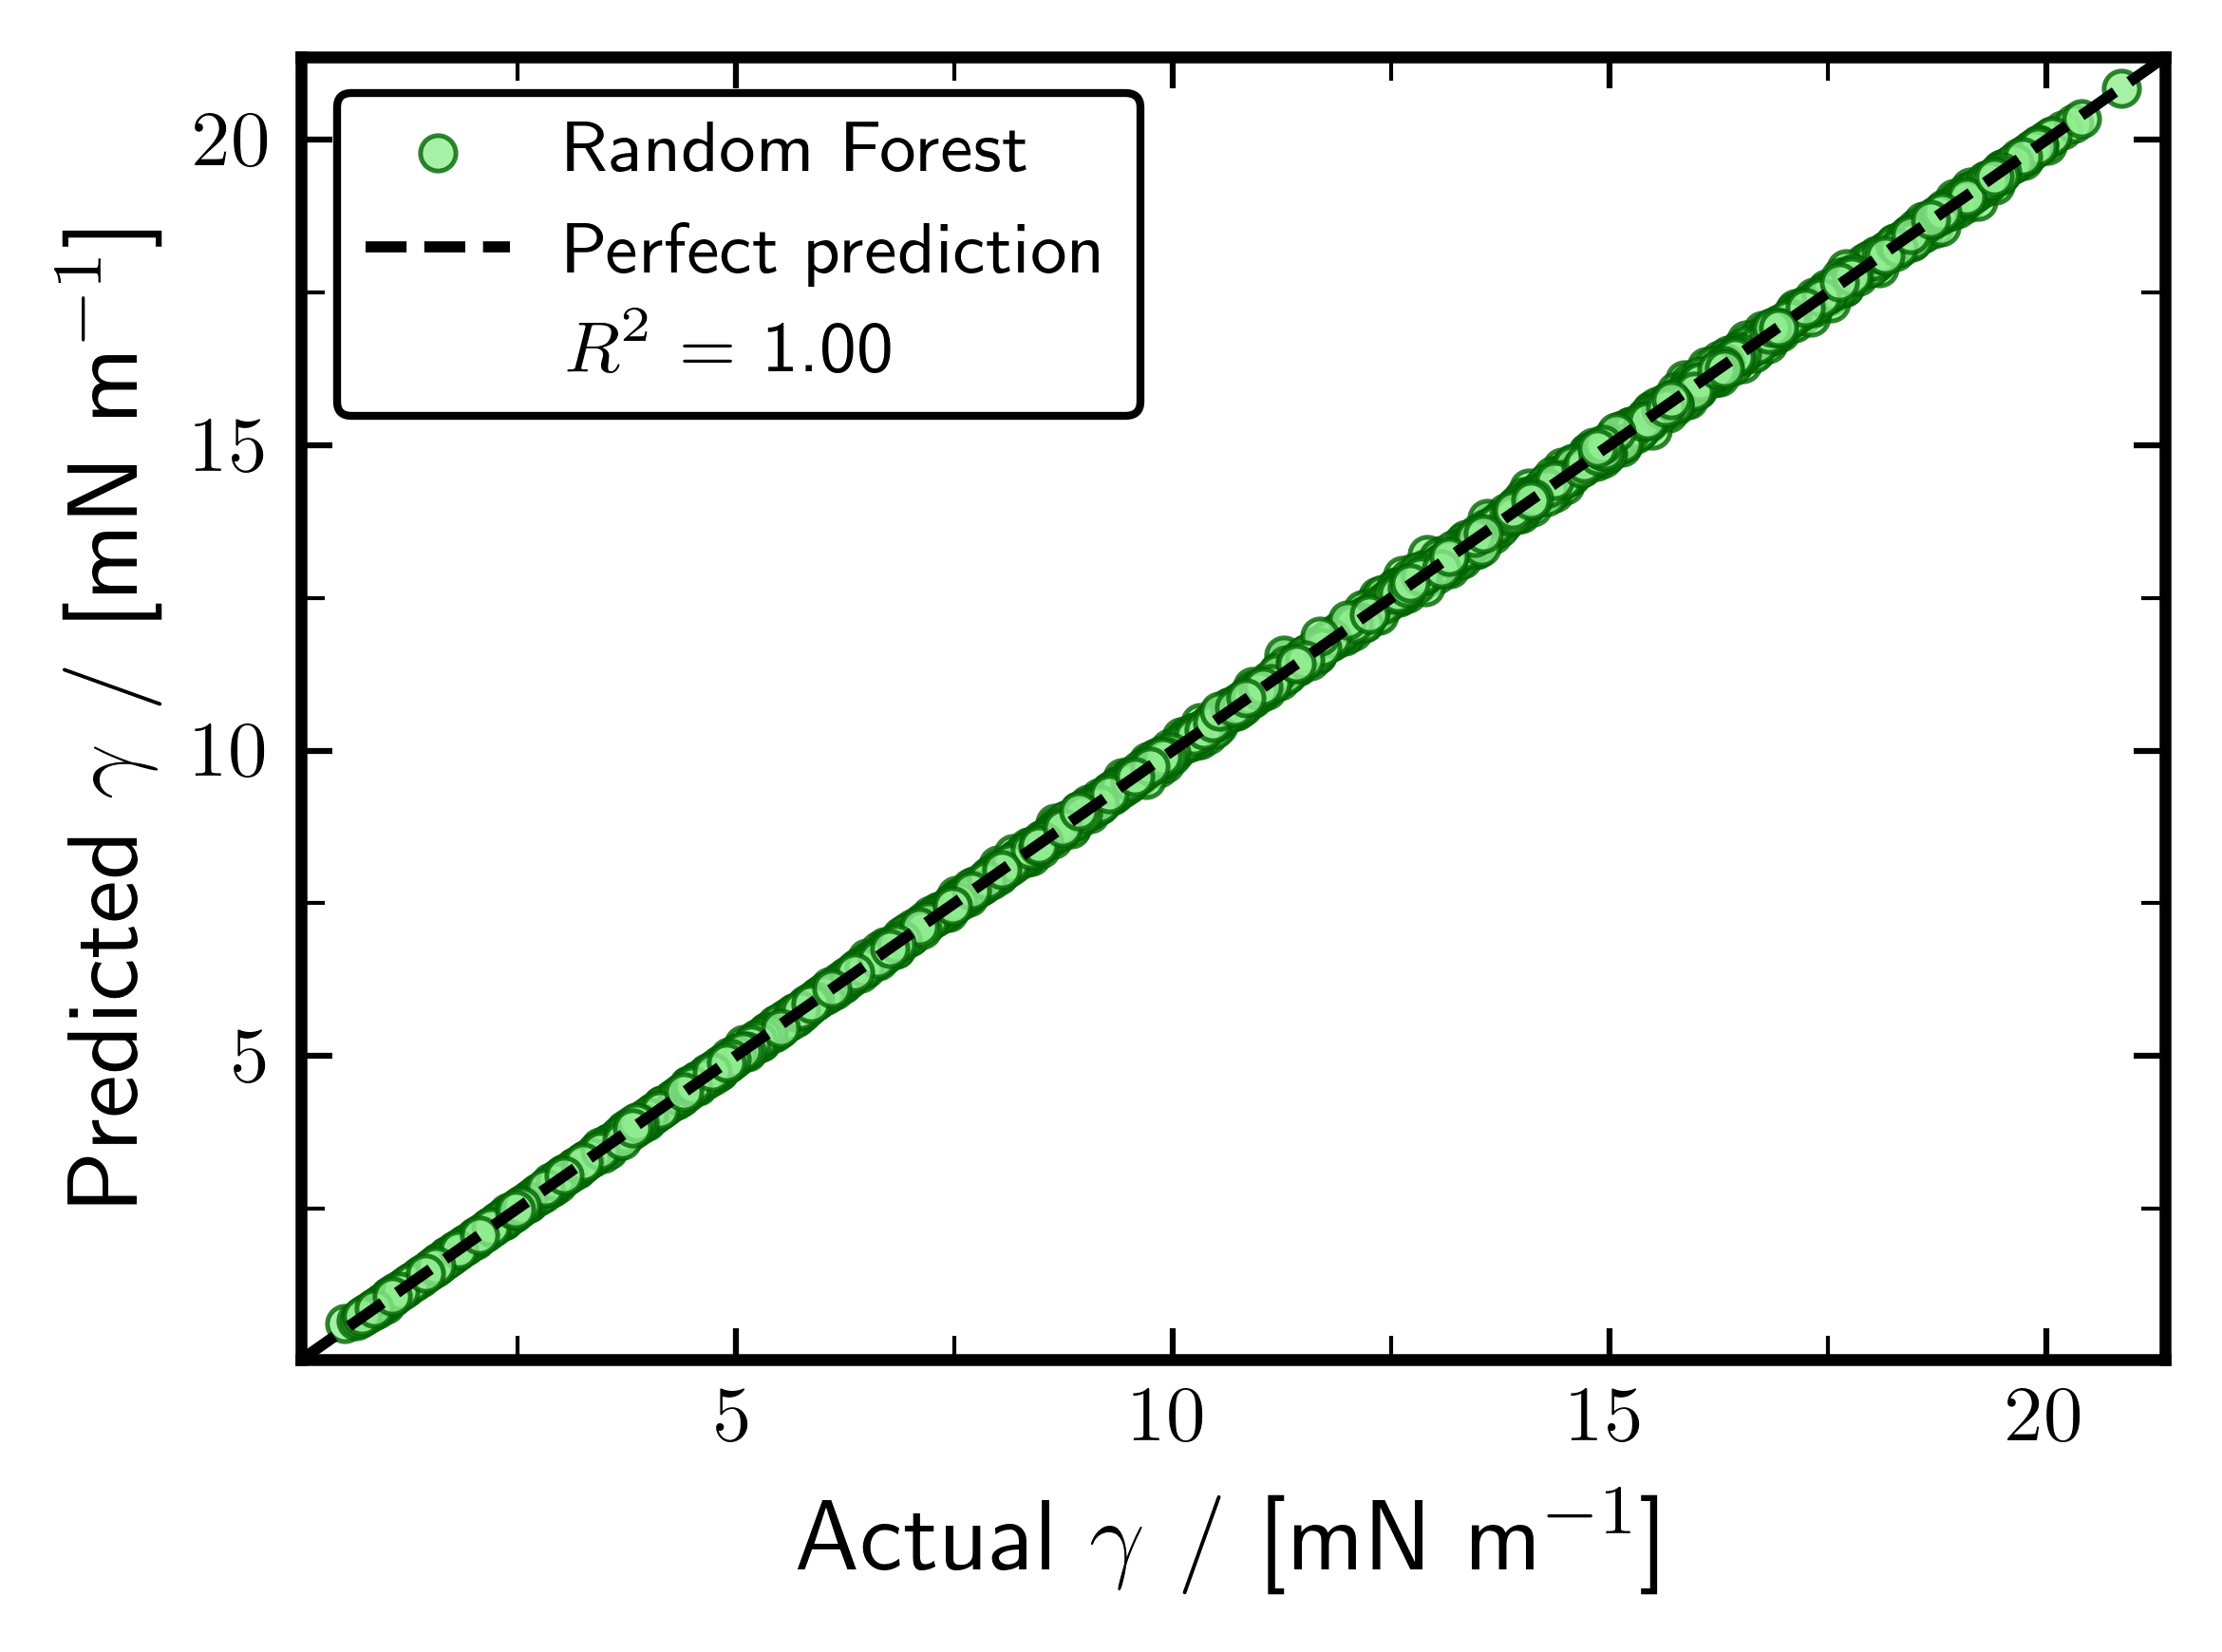

In [16]:
rf_residuals = y_test - y_pred_test

fig, ax = ps.plot_init()

lims = [
    min(y_test.min(), y_pred_test.min()),
    max(y_test.max(), y_pred_test.max())
]
lims = [lims[0] - 0.5, lims[1] + 0.5]

ax.scatter(
    y_test, y_pred_test,
    alpha=0.8, s=20,
    facecolors="lightgreen",
    edgecolors="darkgreen",
    linewidths=0.6,
    label="Random Forest"
)

ax.plot(lims, lims, "k--", linewidth=1.4, label="Perfect prediction")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r"Actual $\gamma$ / [mN m$^{-1}$]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Predicted $\gamma$ / [mN m$^{-1}$]", fontsize=ps.label_fontsize * 0.9)

ps.apply_axis_style(ax)
dummy_r2 = Line2D([], [], linestyle="none", label=rf"$R^2$ = {r2_test:.2f}")

handles, labels = ax.get_legend_handles_labels()
handles.append(dummy_r2)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.65,
    loc="upper left",
    edgecolor="black",
    framealpha=1.0
)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "rf_parity_plot")
plt.show()

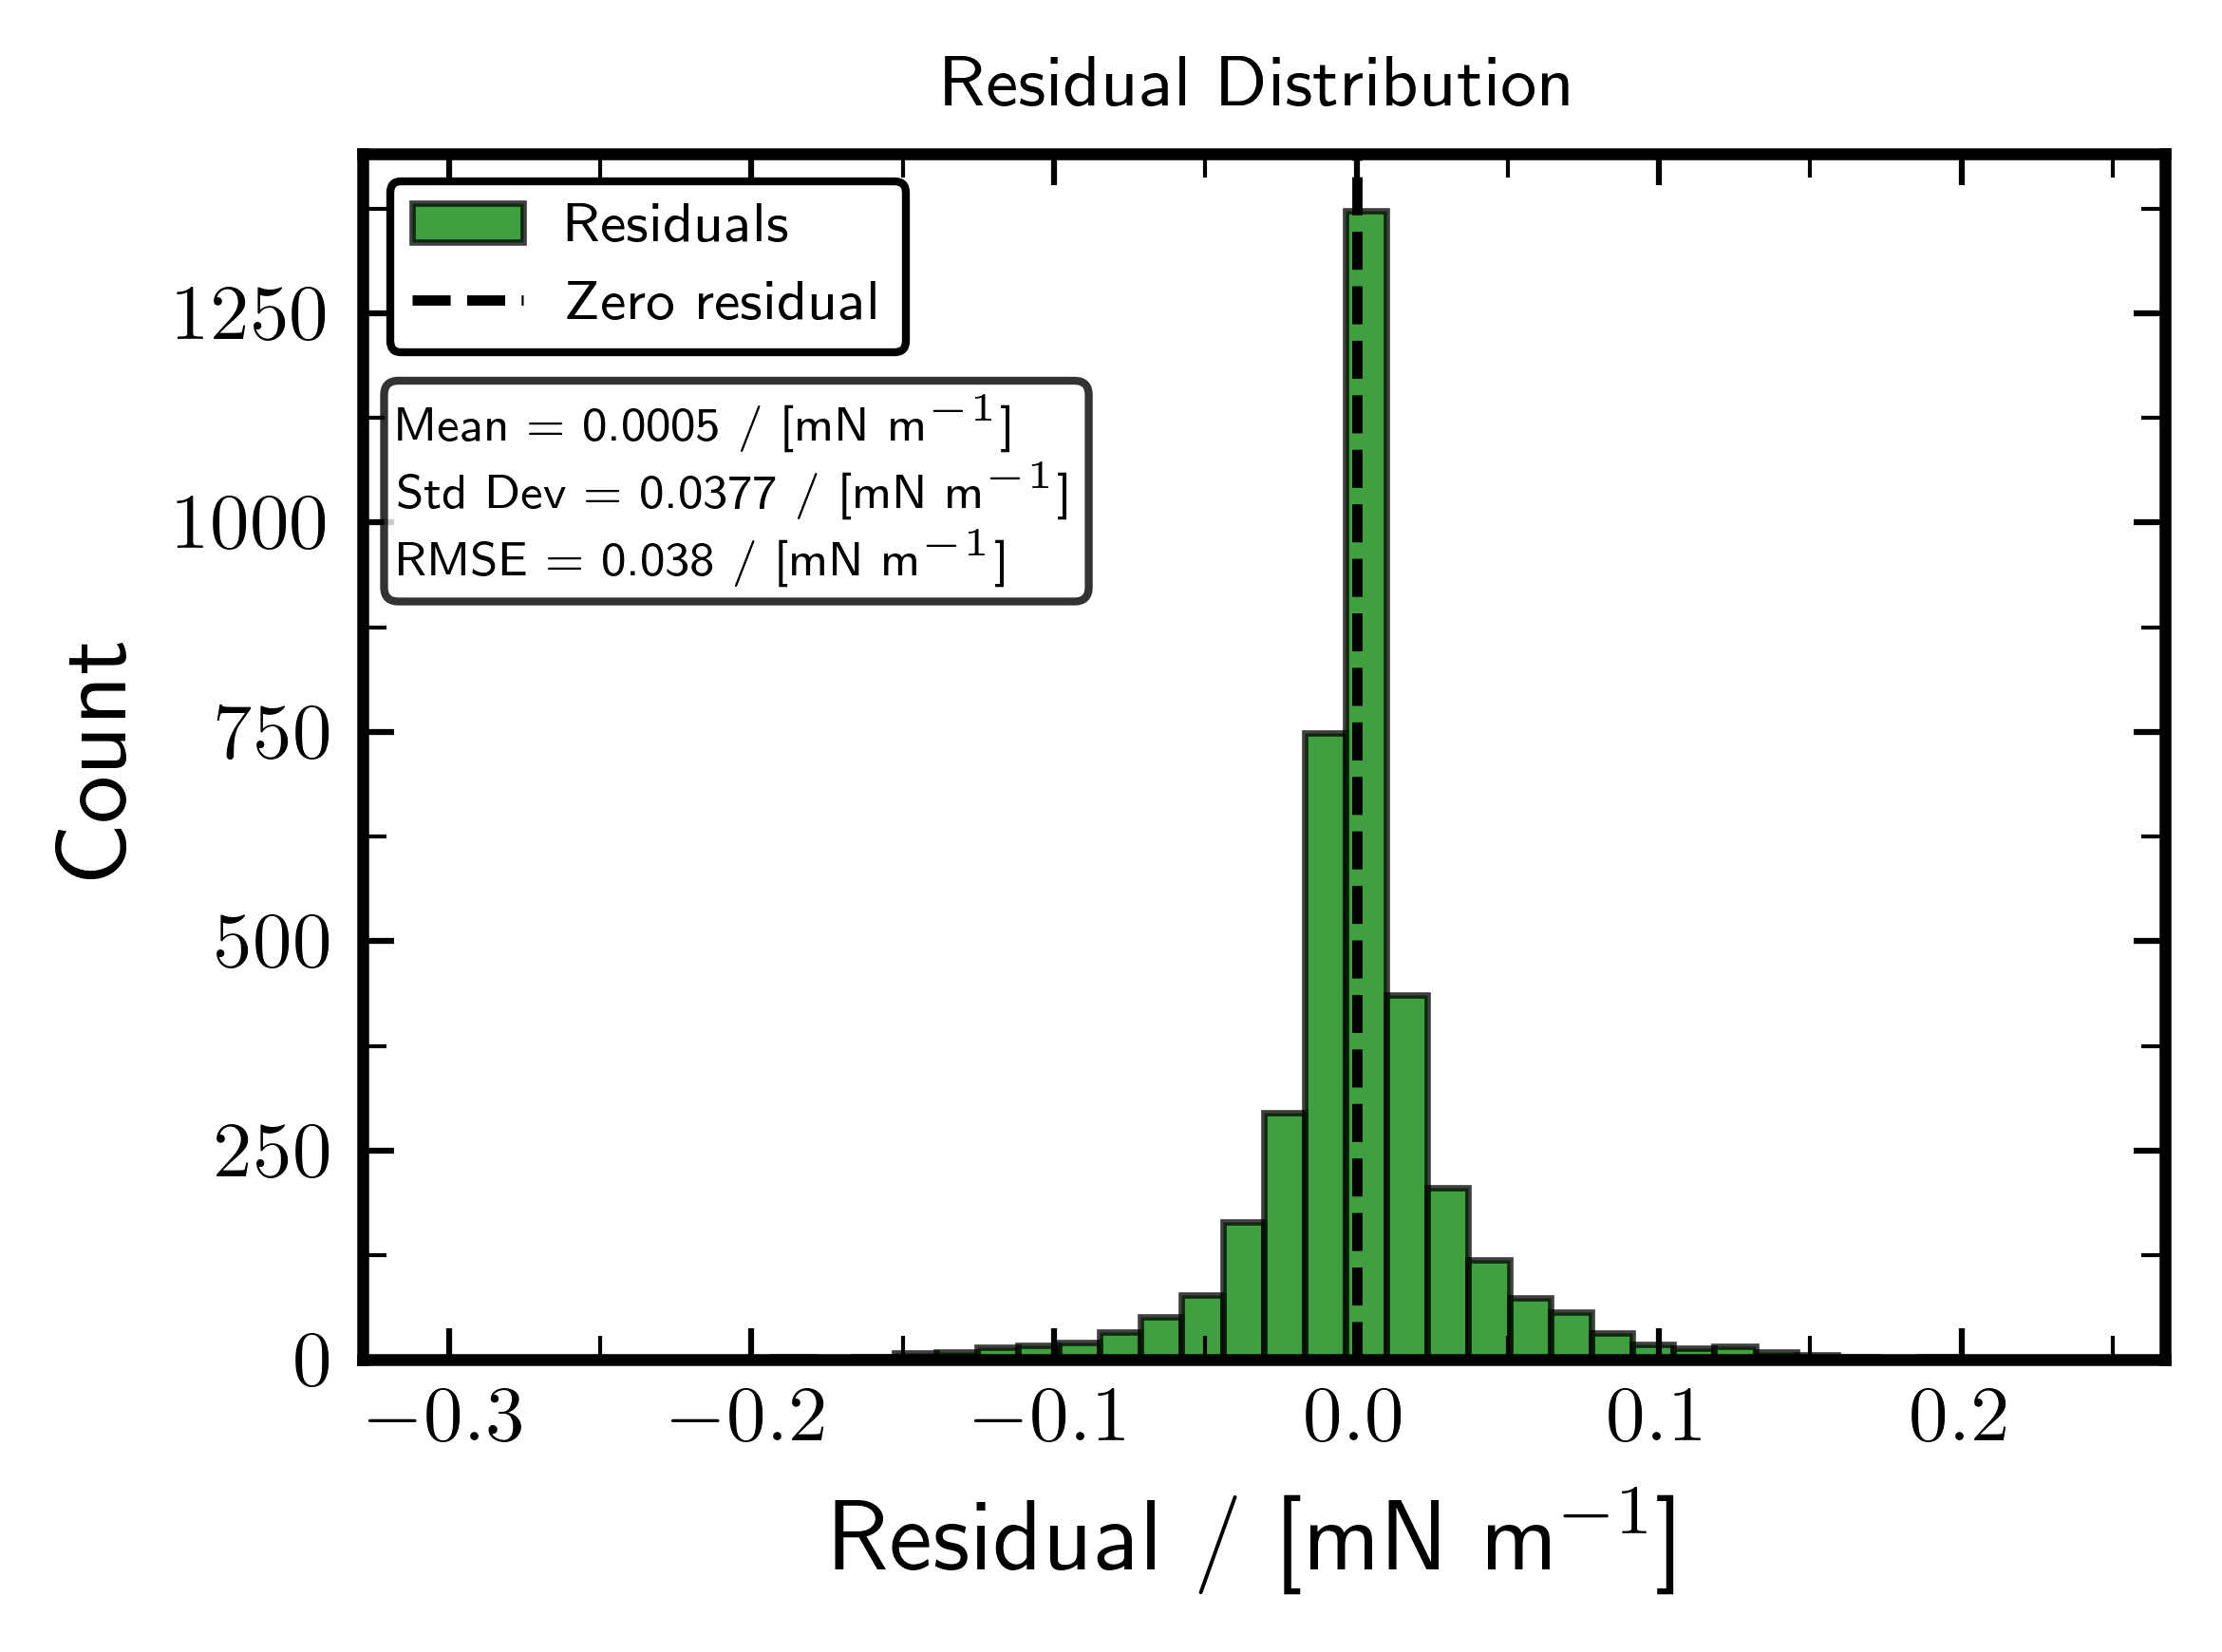

In [17]:
fig, ax = ps.plot_init()

ax.hist(
    rf_residuals,
    bins=40,
    alpha=0.75,
    color="green",
    edgecolor="black",
    linewidth=0.8,
    label="Residuals"
)

ax.axvline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")

mean_resid = rf_residuals.mean()
std_resid = rf_residuals.std()

ax.set_xlabel(r"Residual / [mN m$^{-1}$]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Count", fontsize=ps.label_fontsize * 0.9)
ax.set_title(r"Residual Distribution", fontsize=ps.title_fontsize * 0.75, fontweight="bold")

# dummy_mean = Line2D([], [], linestyle="none", label=rf"Mean = {mean_resid:.4f} / [mN m$^{{-1}}$]")
# dummy_std  = Line2D([], [], linestyle="none", label=rf"Std Dev = {std_resid:.4f} / [mN m$^{{-1}}$]")
# dummy_rmse = Line2D([], [], linestyle="none", label=rf"RMSE = {rmse_test:.3f} / [mN m$^{{-1}}$]")

handles, labels = ax.get_legend_handles_labels()
# handles.extend([dummy_mean, dummy_std, dummy_rmse])

textstr = (
    f"Mean = {mean_resid:.4f} / [mN m$^{{-1}}$]\n"
    f"Std Dev = {std_resid:.4f} / [mN m$^{{-1}}$]\n"
    f"RMSE = {rmse_test:.3f} / [mN m$^{{-1}}$]"
)

ax.text(
    0.02, 0.8, textstr,
    transform=ax.transAxes,
    fontsize=6,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

ps.apply_axis_style(ax)

ax.legend(
    handles=handles,
    fontsize=ps.label_fontsize * 0.5,
    loc="upper left",
    edgecolor="black",
    facecolor="white",
    framealpha=1.0
)

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "rf_residual_distribution")
plt.show()

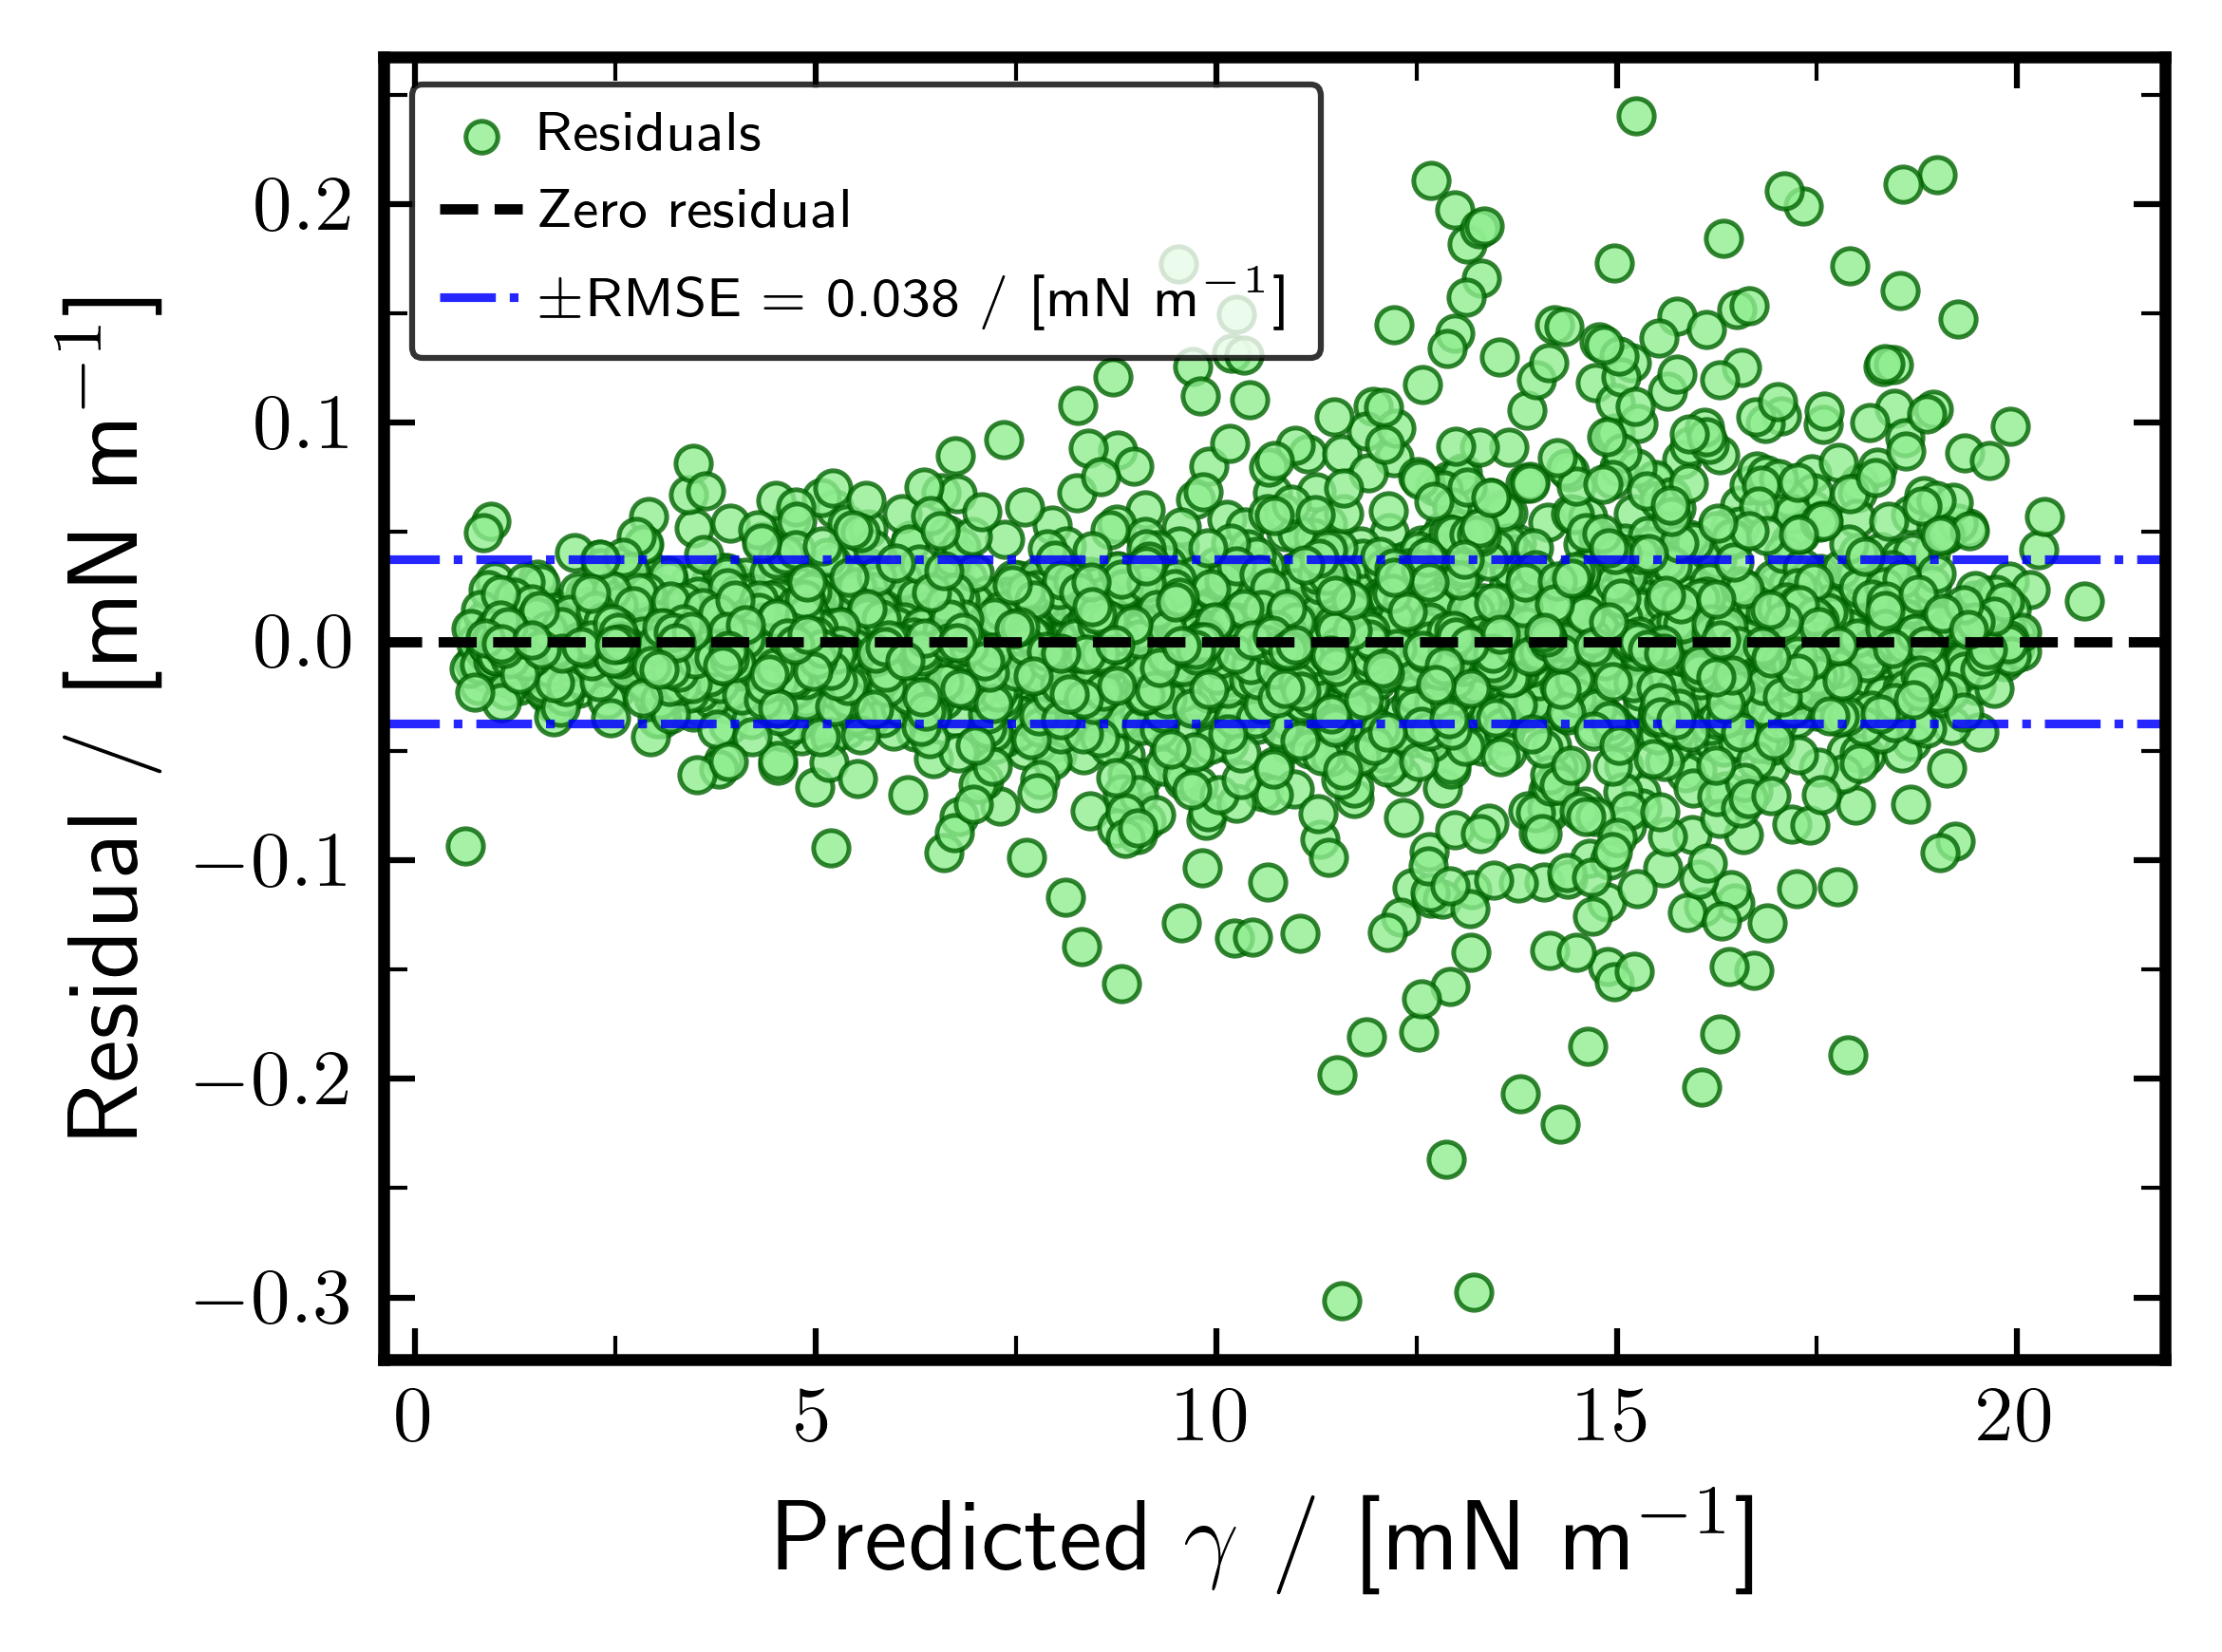

In [18]:
fig, ax = ps.plot_init()

ax.scatter(y_pred_test, rf_residuals, alpha=0.8, s=20, facecolors="lightgreen", edgecolors="darkgreen", linewidths=0.6, label="Residuals")

ax.axhline(0, color="black", linewidth=1.3, linestyle="--", label="Zero residual")

ax.axhline(rmse_test, color="blue", linewidth=1.1, linestyle="-.", alpha=0.85, label=rf"$\pm$RMSE = {rmse_test:.3f} / [mN m$^{{-1}}$]")

ax.axhline(-rmse_test, color="blue", linewidth=1.1, linestyle="-.", alpha=0.85)

ax.set_xlabel(r"Predicted $\gamma$ / [mN m$^{-1}$]", fontsize=ps.label_fontsize * 0.9)
ax.set_ylabel(r"Residual / [mN m$^{-1}$]", fontsize=ps.label_fontsize * 0.9)

ps.apply_axis_style(ax)
ps.style_legend(ax, fontsize=ps.label_fontsize * 0.5, loc="upper left")

ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis="both", which="minor", length=3)

plt.tight_layout()
ps.save_plot(fig, "rf_residual_vs_predicted")
plt.show()

In [19]:
# 5-fold Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

5-FOLD CROSS-VALIDATION RESULTS
Cross-Validation R² Scores: [0.99873535 0.99941366 0.99859243 0.99918327 0.99874591]
Mean CV R²: 0.9989 (+/- 0.0006)


In [20]:
print("=" * 70)
print("SUMMARY: Random Forest Model for gamma Prediction")
print("=" * 70)
print(f"\nModel Configuration:")
print(f"  - n_estimators: {model.n_estimators}")
print(f"  - max_depth: {model.max_depth}")
print(f"  - Features used: {feature_cols}")
print(f"\nPerformance Metrics (Training Set):")
print(f"  - R²:   {r2_train:.6f}")
print(f"  - RMSE: {rmse_train:.6f} mN/m")
print(f"\nPerformance Metrics (Test Set):")
print(f"  - R²:   {r2_test:.6f}")
print(f"  - RMSE: {rmse_test:.6f} mN/m")
print(f"\nCross-Validation:")
print(f"  - Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"\nFeature Importances:")
for fname, val, pct in sorted(zip(feat_names, imp_vals, imp_percent), key=lambda x: x[2], reverse=True):
    bar_length = int(pct / 2)
    bar = "█" * bar_length
    print(f"  {fname:20s} | {pct:6.2f}% | {bar}")

SUMMARY: Random Forest Model for gamma Prediction

Model Configuration:
  - n_estimators: 100
  - max_depth: None
  - Features used: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'z_nitrogen', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Performance Metrics (Training Set):
  - R²:   0.999951
  - RMSE: 0.037429 mN/m

Performance Metrics (Test Set):
  - R²:   0.999951
  - RMSE: 0.037726 mN/m

Cross-Validation:
  - Mean CV R²: 0.9989 (+/- 0.0006)

Feature Importances:
  $T$                  |  97.64% | ████████████████████████████████████████████████
  $P$                  |   1.98% | 
  $z_{\mathrm{H_2}}$   |   0.13% | 
  $z_{\mathrm{CO_2}}$  |   0.10% | 
  $z_{\mathrm{CH_4}}$  |   0.05% | 
  $z_{\mathrm{CO}}$    |   0.04% | 
  $z_{\mathrm{H_2S}}$  |   0.02% | 
  $z_{\mathrm{N_2}}$   |   0.01% | 
  $z_{\mathrm{Ar}}$    |   0.01% | 
  $z_{\mathrm{O_2}}$   |   0.01% | 
